# PGBM hyperparameter tuning

In [54]:
# Load data

import pandas as pd
import numpy as np 
import os
os.environ["OMP_NUM_THREADS"] = "7"

train_df = pd.read_parquet("data/train_data.parquet")

train_df.index = pd.to_numeric(train_df.index, errors="coerce")

cols_to_drop = ["issue_d", "earliest_cr_line"]
train_df = train_df.drop(columns=cols_to_drop, errors="ignore")

In [55]:
# Separate features and targets

train_full_X = train_df.drop(["target", "target_annual_roi"], axis=1)
train_full_y_cat = train_df["target"]
train_full_y_reg = train_df["target_annual_roi"]

# Drop datetime features from the feature set

cols_to_drop = ["issue_d", "earliest_cr_line"]
train_full_X = train_full_X.drop(columns=cols_to_drop, errors="ignore")

In [56]:
# Create subsets of the data for different training sizes - chronological order is preserved, so we take the last N rows for each subset

train_1k_X = train_full_X.tail(1000)
train_1k_y_cat = train_full_y_cat.tail(1000)
train_1k_y_reg = train_full_y_reg.tail(1000)

train_10k_X = train_full_X.tail(10000)
train_10k_y_cat = train_full_y_cat.tail(10000)
train_10k_y_reg = train_full_y_reg.tail(10000)

train_100k_X = train_full_X.tail(100000)
train_100k_y_cat = train_full_y_cat.tail(100000)
train_100k_y_reg = train_full_y_reg.tail(100000)

In [57]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

cols_to_nominal_cat = train_df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical columns:")
for col in cols_to_nominal_cat:
    print(f"- {col}")

cardinality = train_df[cols_to_nominal_cat].nunique()
threshold_for_ohe = 5

cols_for_ohe = cardinality[cardinality <= threshold_for_ohe].index.tolist()
cols_for_te = cardinality[cardinality > threshold_for_ohe].index.tolist()

ohe_categories = []
for col in cols_for_ohe:
    unique_cats = train_df[col].dropna().unique().tolist()
    ohe_categories.append(unique_cats)

ohe_transformer = OneHotEncoder(
    categories=ohe_categories, 
    drop="if_binary", 
    handle_unknown="ignore", 
    sparse_output=False
)

target_transformer_nominal = TargetEncoder(target_type="continuous", smooth="auto")

numeric_preprocessor = ColumnTransformer(
    transformers=[
        ("ohe", ohe_transformer, cols_for_ohe),
        ("target_enc", target_transformer_nominal, cols_for_te)
    ],
    remainder="passthrough", 
    verbose_feature_names_out=False
).set_output(transform="pandas")

imputed_numeric_preprocessor = make_pipeline(
    numeric_preprocessor,
    SimpleImputer(strategy="median")
).set_output(transform="pandas")

gbdt_preprocessor = "passthrough"

Categorical columns:
- home_ownership
- verification_status
- purpose
- addr_state
- initial_list_status
- application_type
- disbursement_method


## Regression - RMSE

[Parameters](https://pgbm.readthedocs.io/en/latest/parameters_sklearn.html)

### 1k

In [37]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from pgbm.sklearn import HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from pgbm.sklearn import crps_ensemble
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)


# Parameter tuning settings

timeout_seconds = 60*60*0.5
no_improvement_trials = 100

# Split the 1k dataset to evaluate on holdout after tuning
# Had problem with overfitting and extreme bad results on last 200 rows so switched the order

X_tuning = train_1k_X.tail(800)
y_tuning = train_1k_y_reg.tail(800)
X_val_holdout = train_1k_X.head(200)
y_val_holdout = train_1k_y_reg.head(200)

def objective_pgbm(trial):
    params = {
        "max_iter": trial.suggest_int("max_iter", 100, 1000), # Number of boosting rounds
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "max_depth": trial.suggest_int("max_depth", 2, 8), # Max tree depth
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 15, 100), # Min samples required in a leaf node
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 3, 31), # Max leaf nodes in the tree
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-5, 100.0, log=True), # L2 regularization term on weights
        "random_state": 42, # For reproducibility
        "verbose": 0, # No verbose output during training
        "max_bins": trial.suggest_int("max_bins", 63, 255), # Maximum number of bins to use for discretizing continuous features
        "tree_correlation": trial.suggest_float("tree_correlation", 1e-4, 0.1, log=True), # Minimum correlation required between trees to allow them to be added to the ensemble
        "distribution": trial.suggest_categorical("distribution", ["normal", "studentt", "laplace", "logistic"]), # Loss function to optimize
        "with_variance": True, # Whether to compute variance estimates for predictions
    }

    if params["distribution"] == "studentt":
        params["studentt_degrees_of_freedom"] = trial.suggest_float("studentt_degrees_of_freedom", 2.0, 30.0) # Degrees of freedom for Student's t distribution

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        HistGradientBoostingRegressor(**params)
    )
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr, y_val = y_tuning.iloc[train_idx], y_tuning.iloc[val_idx]
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            full_pipeline.fit(X_tr, y_tr)
        
        preds_point, preds_std = full_pipeline.predict(X_val, return_std=True)
        
        rmse = np.sqrt(mean_squared_error(y_val, preds_point))
        cv_scores.append(rmse)
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best RMSE for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_pgbm = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_pgbm.optimize(objective_pgbm, timeout=timeout_seconds, n_jobs=1, callbacks=[stop_optuna], show_progress_bar=False)

print("\n" + "="*40)
print(f"BEST RMSE: {study_pgbm.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_pgbm.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_pgbm)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_pgbm)
fig1.show()
    
fig2 = plot_param_importances(study_pgbm)
fig2.show()
    
fig3 = plot_parallel_coordinate(
    study_pgbm,
    params=[
        "max_iter", 
        "learning_rate", 
        "max_depth", 
        "min_samples_leaf", 
        "max_leaf_nodes", 
        "l2_regularization",
        "max_bins",
        "tree_correlation",
        "distribution",
    ]
    )
fig3.show()
    
fig1.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_rmse_1k_history.html")
fig2.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_rmse_1k_importance.html")
fig3.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_rmse_1k_parallel.html")


[I 2026-04-27 01:42:31,939] A new study created in memory with name: no-name-1e661842-bb87-468e-80b8-1ca165eb61b2
[I 2026-04-27 01:42:35,856] Trial 0 finished with value: 0.3745661694070839 and parameters: {'max_iter': 437, 'learning_rate': 0.1667521176194013, 'max_depth': 7, 'min_samples_leaf': 66, 'max_leaf_nodes': 7, 'l2_regularization': 0.0001235838277230692, 'max_bins': 74, 'tree_correlation': 0.0396760507705299, 'distribution': 'logistic'}. Best is trial 0 with value: 0.3745661694070839.
[I 2026-04-27 01:42:41,209] Trial 1 finished with value: 0.3595378146765329 and parameters: {'max_iter': 850, 'learning_rate': 0.010943342660062645, 'max_depth': 3, 'min_samples_leaf': 30, 'max_leaf_nodes': 11, 'l2_regularization': 0.047129737561107825, 'max_bins': 146, 'tree_correlation': 0.0007476312062252305, 'distribution': 'normal'}. Best is trial 1 with value: 0.3595378146765329.
[I 2026-04-27 01:42:43,910] Trial 2 finished with value: 0.37469841479095917 and parameters: {'max_iter': 510, '


[Early Stop] No improvement in 100 trials. Stopping optimization.

BEST RMSE: 0.3490
BEST PARAMETERS:
best_params = {
    "max_iter": 266,
    "learning_rate": 0.0057633608637110215,
    "max_depth": 2,
    "min_samples_leaf": 80,
    "max_leaf_nodes": 24,
    "l2_regularization": 3.757726025937608e-05,
    "max_bins": 106,
    "tree_correlation": 0.00017249809953907554,
    "distribution": "laplace",
}

--- PARAMETER IMPORTANCE ---
  learning_rate       : 0.7902
  max_iter            : 0.0810
  max_depth           : 0.0417
  min_samples_leaf    : 0.0297
  distribution        : 0.0278
  max_leaf_nodes      : 0.0186
  max_bins            : 0.0092
  tree_correlation    : 0.0016
  l2_regularization   : 0.0004


In [ ]:
# Check overfit on holdout set with best parameters from tuning

best_params = study_pgbm.best_params.copy()
best_params["random_state"] = 42
best_params["verbose"] = 0
best_params["with_variance"] = True
print(f"BEST PARAMS: {best_params}")

final_pipeline = make_pipeline(
    numeric_preprocessor,
    HistGradientBoostingRegressor(**best_params)
)

final_pipeline.fit(X_tuning, y_tuning)
holdout_point, holdout_std = final_pipeline.predict(X_val_holdout, return_std=True)
holdout_dist = final_pipeline.named_steps['histgradientboostingregressor'].sample(holdout_point, holdout_std, n_estimates=1000)

holdout_crps = crps_ensemble(holdout_dist, y_val_holdout.values)
holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout.values, holdout_point))

print("\n" + "="*40)
print(f"Optuna Val RMSE:   {study_pgbm.best_value:.4f}")
print(f"Holdout Test CRPS: {holdout_crps:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("="*40)

BEST PARAMS: {'max_iter': 266, 'learning_rate': 0.0057633608637110215, 'max_depth': 2, 'min_samples_leaf': 80, 'max_leaf_nodes': 24, 'l2_regularization': 3.757726025937608e-05, 'max_bins': 106, 'tree_correlation': 0.00017249809953907554, 'distribution': 'laplace', 'random_state': 42, 'verbose': 0, 'with_variance': True}

Optuna Val RMSE:   0.3490
Holdout Test CRPS: 0.1948
Holdout Test RMSE: 0.2919


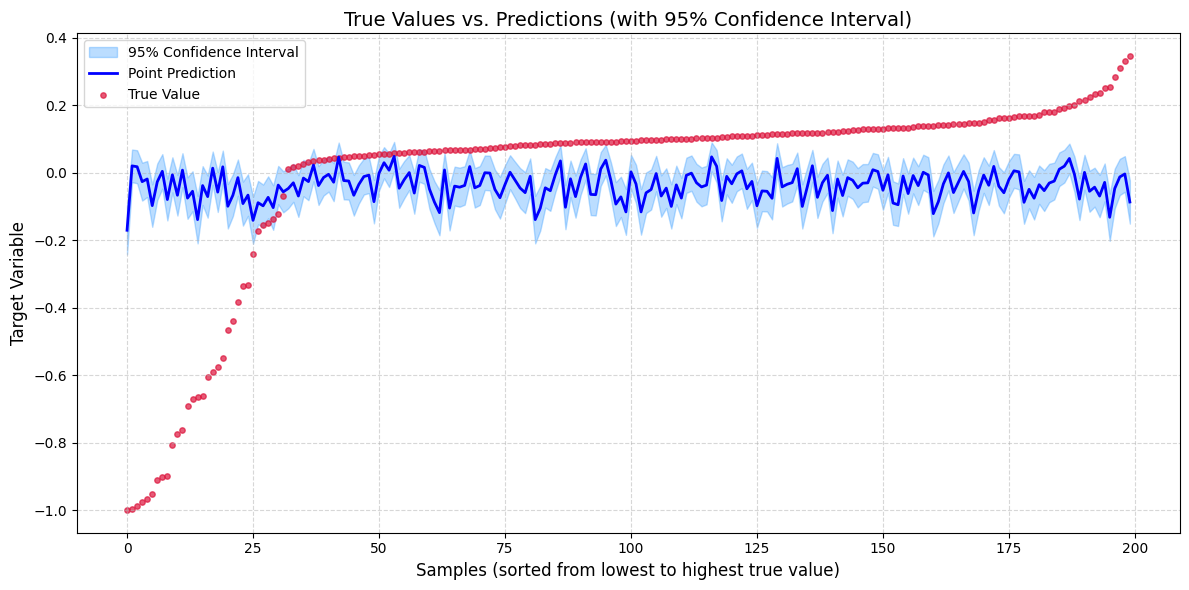

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the bounds of the 95% confidence interval (Z-score is approx. 1.96)
z_score = 1.96
lower_bound = holdout_point - z_score * holdout_std
upper_bound = holdout_point + z_score * holdout_std

sort_idx = np.argsort(y_val_holdout.values)
y_true_sorted = y_val_holdout.values[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

plt.figure(figsize=(12, 6))

plt.fill_between(range(len(y_true_sorted)), lower_sorted, upper_sorted, 
                 color='dodgerblue', alpha=0.3, label='95% Confidence Interval')

plt.plot(range(len(y_true_sorted)), y_pred_sorted, color='blue', linewidth=2, label='Point Prediction')

plt.scatter(range(len(y_true_sorted)), y_true_sorted, color='crimson', s=15, alpha=0.7, label='True Value')

plt.title('True Values vs. Predictions (with 95% Confidence Interval)', fontsize=14)
plt.xlabel('Samples (sorted from lowest to highest true value)', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

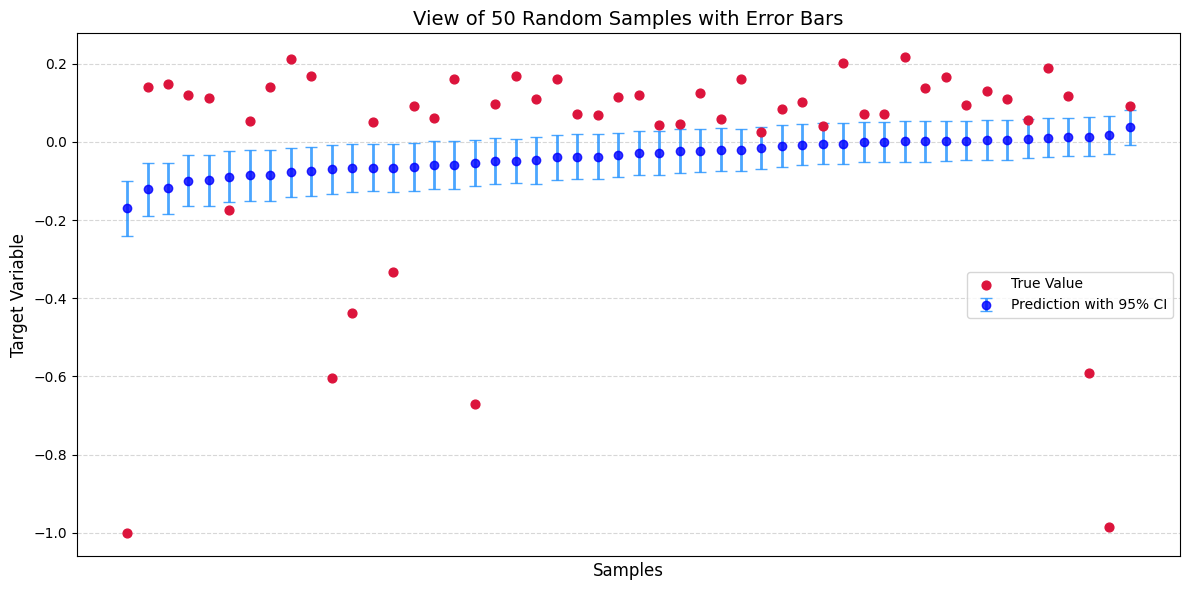

In [40]:
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

y_true_sample = y_val_holdout.values[sample_idx]
y_pred_sample = holdout_point[sample_idx]
std_sample = holdout_std[sample_idx]

sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
std_sample = std_sample[sort_idx]

plt.figure(figsize=(12, 6))

plt.errorbar(range(n_samples), y_pred_sample, yerr=1.96 * std_sample, 
             fmt='o', color='blue', ecolor='dodgerblue', elinewidth=2, capsize=4, 
             alpha=0.8, label='Prediction with 95% CI')

plt.scatter(range(n_samples), y_true_sample, color='crimson', s=40, zorder=3, label='True Value')

plt.title(f'View of {n_samples} Random Samples with Error Bars', fontsize=14)
plt.xlabel('Samples', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 10k

In [41]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from pgbm.sklearn import HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from pgbm.sklearn import crps_ensemble


# Parameter tuning settings

timeout_seconds = 60*60*1
no_improvement_trials = 100

# Split the 10k dataset to evaluate on holdout after tuning

X_tuning = train_10k_X.head(8000)
y_tuning = train_10k_y_reg.head(8000)
X_val_holdout = train_10k_X.tail(2000)
y_val_holdout = train_10k_y_reg.tail(2000)

def objective_pgbm(trial):
    params = {
        "max_iter": trial.suggest_int("max_iter", 100, 1000), # Number of boosting rounds
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "max_depth": trial.suggest_int("max_depth", 2, 8), # Max tree depth
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 15, 100), # Min samples required in a leaf node
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 3, 31), # Max leaf nodes in the tree
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-5, 100.0, log=True), # L2 regularization term on weights
        "random_state": 42, # For reproducibility
        "verbose": 0, # No verbose output during training
        "max_bins": trial.suggest_int("max_bins", 63, 255), # Maximum number of bins to use for discretizing continuous features
        "tree_correlation": trial.suggest_float("tree_correlation", 1e-4, 0.1, log=True), # Minimum correlation required between trees to allow them to be added to the ensemble
        "distribution": trial.suggest_categorical("distribution", ["normal", "studentt", "laplace", "logistic"]), # Loss function to optimize
        "with_variance": True # Whether to compute variance estimates for predictions
    }

    if params["distribution"] == "studentt":
        params["studentt_degrees_of_freedom"] = trial.suggest_float("studentt_degrees_of_freedom", 2.0, 30.0) # Degrees of freedom for Student's t distribution

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        HistGradientBoostingRegressor(**params)
    )
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr, y_val = y_tuning.iloc[train_idx], y_tuning.iloc[val_idx]
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            full_pipeline.fit(X_tr, y_tr)
        
        preds_point, preds_std = full_pipeline.predict(X_val, return_std=True)
        
        rmse = np.sqrt(mean_squared_error(y_val, preds_point))
        cv_scores.append(rmse)
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best RMSE for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_pgbm = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_pgbm.optimize(objective_pgbm, timeout=timeout_seconds, n_jobs=1, callbacks=[stop_optuna], show_progress_bar=False)

print("\n" + "="*40)
print(f"BEST RMSE: {study_pgbm.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_pgbm.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_pgbm)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_pgbm)
fig1.show()
    
fig2 = plot_param_importances(study_pgbm)
fig2.show()
    
fig3 = plot_parallel_coordinate(
    study_pgbm,
    params=[
        "max_iter", 
        "learning_rate", 
        "max_depth", 
        "min_samples_leaf", 
        "max_leaf_nodes", 
        "l2_regularization",
        "max_bins",
        "tree_correlation",
        "distribution",
    ]
    )
fig3.show()
    
fig1.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_rmse_10k_history.html")
fig2.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_rmse_10k_importance.html")
fig3.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_rmse_10k_parallel.html")


[I 2026-04-27 01:45:43,543] A new study created in memory with name: no-name-83ef5df7-8746-41b6-8c2a-d8806364eb70
[I 2026-04-27 01:45:48,609] Trial 0 finished with value: 0.3008567469777944 and parameters: {'max_iter': 437, 'learning_rate': 0.1667521176194013, 'max_depth': 7, 'min_samples_leaf': 66, 'max_leaf_nodes': 7, 'l2_regularization': 0.0001235838277230692, 'max_bins': 74, 'tree_correlation': 0.0396760507705299, 'distribution': 'logistic'}. Best is trial 0 with value: 0.3008567469777944.
[I 2026-04-27 01:45:55,837] Trial 1 finished with value: 0.2879297236268586 and parameters: {'max_iter': 850, 'learning_rate': 0.010943342660062645, 'max_depth': 3, 'min_samples_leaf': 30, 'max_leaf_nodes': 11, 'l2_regularization': 0.047129737561107825, 'max_bins': 146, 'tree_correlation': 0.0007476312062252305, 'distribution': 'normal'}. Best is trial 1 with value: 0.2879297236268586.
[I 2026-04-27 01:46:00,006] Trial 2 finished with value: 0.29474901257850483 and parameters: {'max_iter': 510, '


[Early Stop] No improvement in 100 trials. Stopping optimization.

BEST RMSE: 0.2861
BEST PARAMETERS:
best_params = {
    "max_iter": 335,
    "learning_rate": 0.009284324112102069,
    "max_depth": 6,
    "min_samples_leaf": 26,
    "max_leaf_nodes": 8,
    "l2_regularization": 86.43849217392876,
    "max_bins": 149,
    "tree_correlation": 0.030672618536641574,
    "distribution": "laplace",
}

--- PARAMETER IMPORTANCE ---
  learning_rate       : 0.7707
  max_leaf_nodes      : 0.0506
  max_depth           : 0.0379
  max_iter            : 0.0333
  max_bins            : 0.0327
  tree_correlation    : 0.0298
  distribution        : 0.0192
  l2_regularization   : 0.0154
  min_samples_leaf    : 0.0104


In [42]:
# Check overfit on holdout set with best parameters from tuning

best_params = study_pgbm.best_params.copy()
best_params["random_state"] = 42
best_params["verbose"] = 0
best_params["with_variance"] = True
best_params["max_iter"] = int(best_params["max_iter"] * 2)
best_params["learning_rate"] = best_params["learning_rate"] / 2
print(f"BEST PARAMS: {best_params}")

final_pipeline = make_pipeline(
    numeric_preprocessor,
    HistGradientBoostingRegressor(**best_params)
)

final_pipeline.fit(X_tuning, y_tuning)
holdout_point, holdout_std = final_pipeline.predict(X_val_holdout, return_std=True)
holdout_dist = final_pipeline.named_steps['histgradientboostingregressor'].sample(holdout_point, holdout_std, n_estimates=1000)

holdout_crps = crps_ensemble(holdout_dist, y_val_holdout.values)
holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout.values, holdout_point))

print("\n" + "="*40)
print(f"Optuna Val RMSE:   {study_pgbm.best_value:.4f}")
print(f"Holdout Test CRPS: {holdout_crps:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("="*40)

BEST PARAMS: {'max_iter': 670, 'learning_rate': 0.0046421620560510345, 'max_depth': 6, 'min_samples_leaf': 26, 'max_leaf_nodes': 8, 'l2_regularization': 86.43849217392876, 'max_bins': 149, 'tree_correlation': 0.030672618536641574, 'distribution': 'laplace', 'random_state': 42, 'verbose': 0, 'with_variance': True}

Optuna Val RMSE:   0.2861
Holdout Test CRPS: 0.2174
Holdout Test RMSE: 0.3209


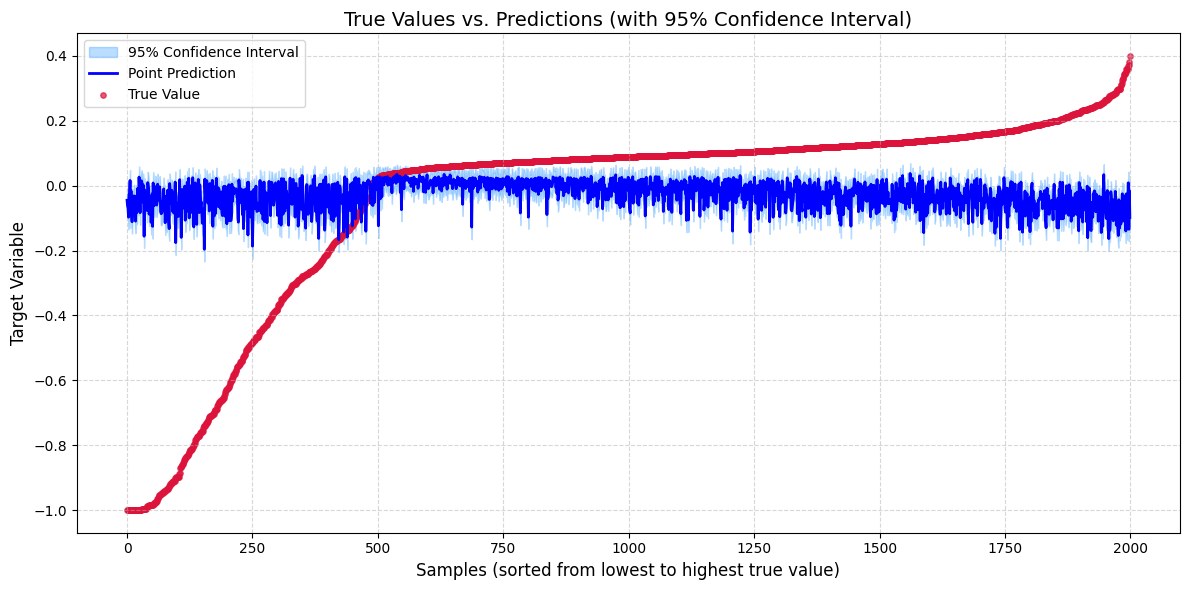

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the bounds of the 95% confidence interval (Z-score is approx. 1.96)
z_score = 1.96
lower_bound = holdout_point - z_score * holdout_std
upper_bound = holdout_point + z_score * holdout_std

sort_idx = np.argsort(y_val_holdout.values)
y_true_sorted = y_val_holdout.values[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

plt.figure(figsize=(12, 6))

plt.fill_between(range(len(y_true_sorted)), lower_sorted, upper_sorted, 
                 color='dodgerblue', alpha=0.3, label='95% Confidence Interval')

plt.plot(range(len(y_true_sorted)), y_pred_sorted, color='blue', linewidth=2, label='Point Prediction')

plt.scatter(range(len(y_true_sorted)), y_true_sorted, color='crimson', s=15, alpha=0.7, label='True Value')

plt.title('True Values vs. Predictions (with 95% Confidence Interval)', fontsize=14)
plt.xlabel('Samples (sorted from lowest to highest true value)', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

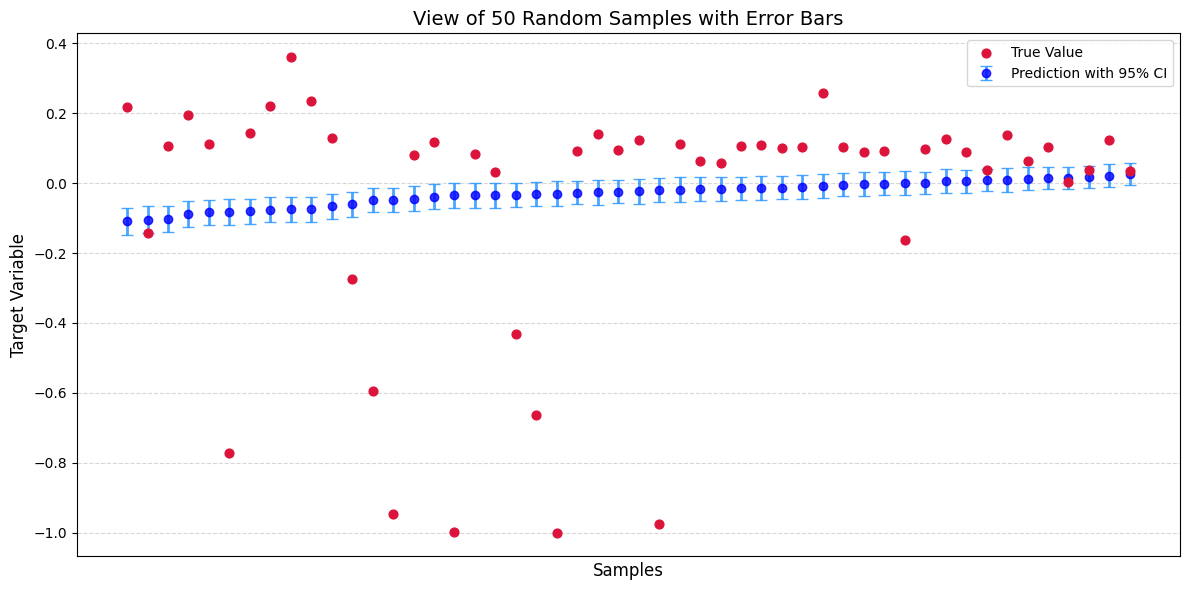

In [44]:
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

y_true_sample = y_val_holdout.values[sample_idx]
y_pred_sample = holdout_point[sample_idx]
std_sample = holdout_std[sample_idx]

sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
std_sample = std_sample[sort_idx]

plt.figure(figsize=(12, 6))

plt.errorbar(range(n_samples), y_pred_sample, yerr=1.96 * std_sample, 
             fmt='o', color='blue', ecolor='dodgerblue', elinewidth=2, capsize=4, 
             alpha=0.8, label='Prediction with 95% CI')

plt.scatter(range(n_samples), y_true_sample, color='crimson', s=40, zorder=3, label='True Value')

plt.title(f'View of {n_samples} Random Samples with Error Bars', fontsize=14)
plt.xlabel('Samples', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 100k

In [45]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from pgbm.sklearn import HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from pgbm.sklearn import crps_ensemble


# Parameter tuning settings

timeout_seconds = 60*60*3
no_improvement_trials = 100

# Split the 100k dataset to evaluate on holdout after tuning

X_tuning = train_100k_X.head(80000)
y_tuning = train_100k_y_reg.head(80000)
X_val_holdout = train_100k_X.tail(20000)
y_val_holdout = train_100k_y_reg.tail(20000)

def objective_pgbm(trial):
    params = {
        "max_iter": trial.suggest_int("max_iter", 100, 1000), # Number of boosting rounds
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.2, log=True), # Step size
        "max_depth": trial.suggest_int("max_depth", 2, 20), # Max tree depth
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 500), # Min samples required in a leaf node
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 5, 512), # Max leaf nodes in the tree
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-5, 100.0, log=True), # L2 regularization term on weights
        "random_state": 42, # For reproducibility
        "verbose": 0, # No verbose output during training
        "max_bins": trial.suggest_int("max_bins", 63, 255), # Maximum number of bins to use for discretizing continuous features
        "tree_correlation": trial.suggest_float("tree_correlation", 1e-4, 0.1, log=True), # Minimum correlation required between trees to allow them to be added to the ensemble
        "distribution": trial.suggest_categorical("distribution", ["normal", "studentt", "laplace", "logistic"]), # Loss function to optimize
        "with_variance": True # Whether to compute variance estimates for predictions
    }

    if params["distribution"] == "studentt":
        params["studentt_degrees_of_freedom"] = trial.suggest_float("studentt_degrees_of_freedom", 2.0, 30.0) # Degrees of freedom for Student's t distribution

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        HistGradientBoostingRegressor(**params)
    )
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr, y_val = y_tuning.iloc[train_idx], y_tuning.iloc[val_idx]
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            full_pipeline.fit(X_tr, y_tr)
        
        preds_point, preds_std = full_pipeline.predict(X_val, return_std=True)
        
        rmse = np.sqrt(mean_squared_error(y_val, preds_point))
        cv_scores.append(rmse)
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best RMSE for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_pgbm = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_pgbm.optimize(objective_pgbm, timeout=timeout_seconds, n_jobs=1, callbacks=[stop_optuna], show_progress_bar=False)

print("\n" + "="*40)
print(f"BEST RMSE: {study_pgbm.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_pgbm.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_pgbm)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_pgbm)
fig1.show()
    
fig2 = plot_param_importances(study_pgbm)
fig2.show()
    
fig3 = plot_parallel_coordinate(
    study_pgbm,
    params=[
        "max_iter", 
        "learning_rate", 
        "max_depth", 
        "min_samples_leaf", 
        "max_leaf_nodes", 
        "l2_regularization",
        "max_bins",
        "tree_correlation",
        "distribution",
    ]
    )
fig3.show()
    
fig1.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_rmse_100k_history.html")
fig2.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_rmse_100k_importance.html")
fig3.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_rmse_100k_parallel.html")

[I 2026-04-27 01:58:17,025] A new study created in memory with name: no-name-1dbc0453-651b-4b3e-97bf-5cc372f6ad98
[I 2026-04-27 01:58:21,847] Trial 0 finished with value: 0.3024325132601031 and parameters: {'max_iter': 437, 'learning_rate': 0.1540359659501924, 'max_depth': 15, 'min_samples_leaf': 303, 'max_leaf_nodes': 84, 'l2_regularization': 0.0001235838277230692, 'max_bins': 74, 'tree_correlation': 0.0396760507705299, 'distribution': 'logistic'}. Best is trial 0 with value: 0.3024325132601031.
[I 2026-04-27 01:59:04,223] Trial 1 finished with value: 0.3024491385831125 and parameters: {'max_iter': 850, 'learning_rate': 0.0030803400529839683, 'max_depth': 5, 'min_samples_leaf': 100, 'max_leaf_nodes': 159, 'l2_regularization': 0.047129737561107825, 'max_bins': 146, 'tree_correlation': 0.0007476312062252305, 'distribution': 'normal'}. Best is trial 0 with value: 0.3024325132601031.
[I 2026-04-27 01:59:08,627] Trial 2 finished with value: 0.30169210817949416 and parameters: {'max_iter': 


[Early Stop] No improvement in 100 trials. Stopping optimization.

BEST RMSE: 0.3012
BEST PARAMETERS:
best_params = {
    "max_iter": 949,
    "learning_rate": 0.06916687738612089,
    "max_depth": 10,
    "min_samples_leaf": 327,
    "max_leaf_nodes": 24,
    "l2_regularization": 14.804147651872958,
    "max_bins": 169,
    "tree_correlation": 0.012392279453673792,
    "distribution": "laplace",
}

--- PARAMETER IMPORTANCE ---
  learning_rate       : 0.5793
  min_samples_leaf    : 0.2430
  max_leaf_nodes      : 0.0851
  max_iter            : 0.0465
  max_bins            : 0.0158
  l2_regularization   : 0.0111
  max_depth           : 0.0104
  distribution        : 0.0044
  tree_correlation    : 0.0044


In [46]:
# Check overfit on holdout set with best parameters from tuning

best_params = study_pgbm.best_params.copy()
best_params["random_state"] = 42
best_params["verbose"] = 0
best_params["with_variance"] = True
best_params["max_iter"] = int(best_params["max_iter"] * 10)
best_params["learning_rate"] = best_params["learning_rate"] / 10
print(f"BEST PARAMS: {best_params}")

final_pipeline = make_pipeline(
    numeric_preprocessor,
    HistGradientBoostingRegressor(**best_params)
)

final_pipeline.fit(X_tuning, y_tuning)
holdout_point, holdout_std = final_pipeline.predict(X_val_holdout, return_std=True)
holdout_dist = final_pipeline.named_steps['histgradientboostingregressor'].sample(holdout_point, holdout_std, n_estimates=1000)

holdout_crps = crps_ensemble(holdout_dist, y_val_holdout.values)
holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout.values, holdout_point))

print("\n" + "="*40)
print(f"Optuna Val RMSE:   {study_pgbm.best_value:.4f}")
print(f"Holdout Test CRPS: {holdout_crps:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("="*40)

BEST PARAMS: {'max_iter': 9490, 'learning_rate': 0.0069166877386120885, 'max_depth': 10, 'min_samples_leaf': 327, 'max_leaf_nodes': 24, 'l2_regularization': 14.804147651872958, 'max_bins': 169, 'tree_correlation': 0.012392279453673792, 'distribution': 'laplace', 'random_state': 42, 'verbose': 0, 'with_variance': True}

Optuna Val RMSE:   0.3012
Holdout Test CRPS: 0.1967
Holdout Test RMSE: 0.3012


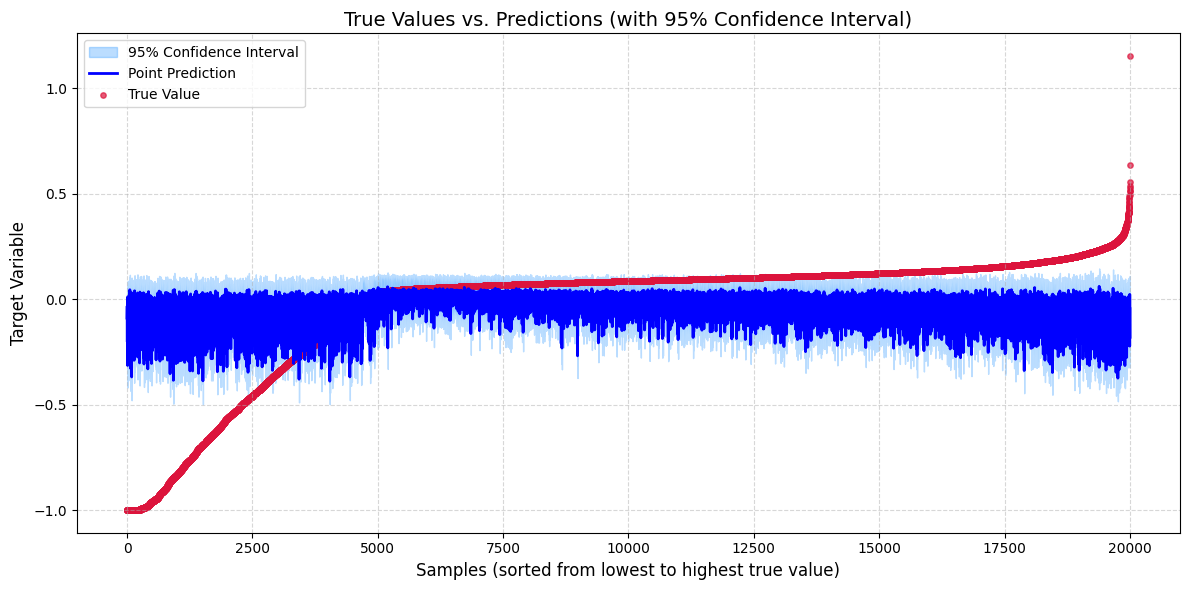

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the bounds of the 95% confidence interval (Z-score is approx. 1.96)
z_score = 1.96
lower_bound = holdout_point - z_score * holdout_std
upper_bound = holdout_point + z_score * holdout_std

sort_idx = np.argsort(y_val_holdout.values)
y_true_sorted = y_val_holdout.values[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

plt.figure(figsize=(12, 6))

plt.fill_between(range(len(y_true_sorted)), lower_sorted, upper_sorted, 
                 color='dodgerblue', alpha=0.3, label='95% Confidence Interval')

plt.plot(range(len(y_true_sorted)), y_pred_sorted, color='blue', linewidth=2, label='Point Prediction')

plt.scatter(range(len(y_true_sorted)), y_true_sorted, color='crimson', s=15, alpha=0.7, label='True Value')

plt.title('True Values vs. Predictions (with 95% Confidence Interval)', fontsize=14)
plt.xlabel('Samples (sorted from lowest to highest true value)', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

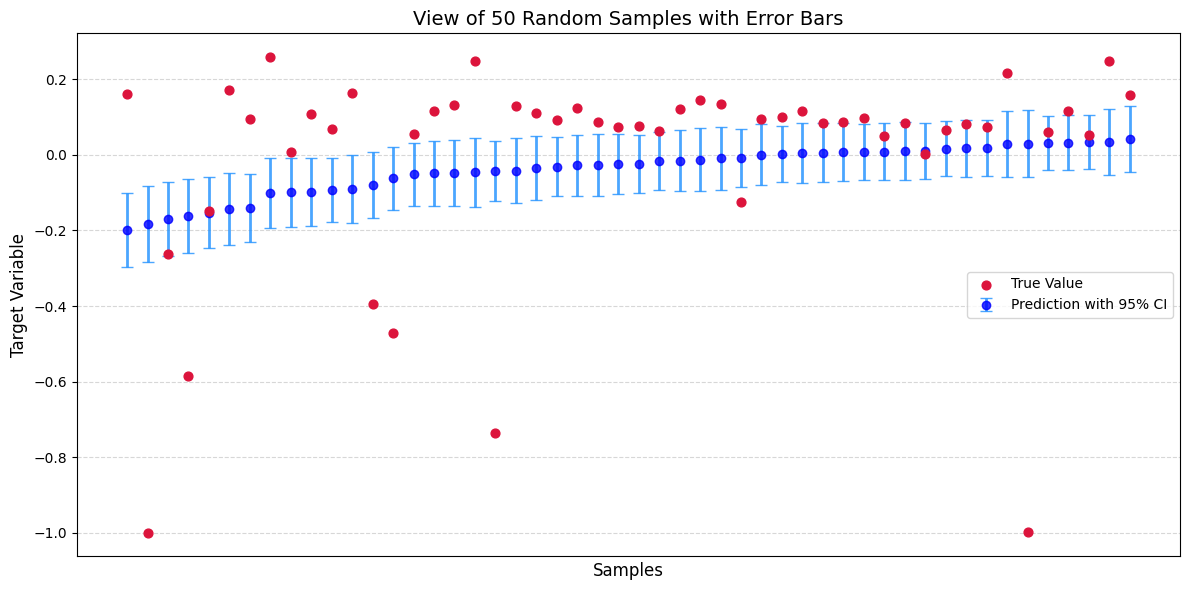

In [48]:
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

y_true_sample = y_val_holdout.values[sample_idx]
y_pred_sample = holdout_point[sample_idx]
std_sample = holdout_std[sample_idx]

sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
std_sample = std_sample[sort_idx]

plt.figure(figsize=(12, 6))

plt.errorbar(range(n_samples), y_pred_sample, yerr=1.96 * std_sample, 
             fmt='o', color='blue', ecolor='dodgerblue', elinewidth=2, capsize=4, 
             alpha=0.8, label='Prediction with 95% CI')

plt.scatter(range(n_samples), y_true_sample, color='crimson', s=40, zorder=3, label='True Value')

plt.title(f'View of {n_samples} Random Samples with Error Bars', fontsize=14)
plt.xlabel('Samples', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Whole training data set

In [49]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from pgbm.sklearn import HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from pgbm.sklearn import crps_ensemble


# Parameter tuning settings

timeout_seconds = 60*60*4
no_improvement_trials = 100

split_index = int(len(train_full_X) * 0.8)

X_tuning = train_full_X[:split_index]
y_tuning = train_full_y_reg[:split_index]
X_val_holdout = train_full_X[split_index:]
y_val_holdout = train_full_y_reg[split_index:]

def objective_pgbm(trial):
    params = {
        "max_iter": trial.suggest_int("max_iter", 100, 1000), # Number of boosting rounds
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.2, log=True), # Step size
        "max_depth": trial.suggest_int("max_depth", 2, 20), # Max tree depth
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 500), # Min samples required in a leaf node
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 5, 512), # Max leaf nodes in the tree
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-5, 100.0, log=True), # L2 regularization term on weights
        "random_state": 42, # For reproducibility
        "verbose": 0, # No verbose output during training
        "max_bins": trial.suggest_int("max_bins", 63, 255), # Maximum number of bins to use for discretizing continuous features
        "tree_correlation": trial.suggest_float("tree_correlation", 1e-4, 0.1, log=True), # Minimum correlation required between trees to allow them to be added to the ensemble
        "distribution": trial.suggest_categorical("distribution", ["normal", "studentt", "laplace", "logistic"]), # Loss function to optimize
        "with_variance": True # Whether to compute variance estimates for predictions
    }

    if params["distribution"] == "studentt":
        params["studentt_degrees_of_freedom"] = trial.suggest_float("studentt_degrees_of_freedom", 2.0, 30.0) # Degrees of freedom for Student's t distribution

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        HistGradientBoostingRegressor(**params)
    )
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr, y_val = y_tuning.iloc[train_idx], y_tuning.iloc[val_idx]
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            full_pipeline.fit(X_tr, y_tr)
        
        preds_point, preds_std = full_pipeline.predict(X_val, return_std=True)
        
        rmse = np.sqrt(mean_squared_error(y_val, preds_point))
        cv_scores.append(rmse)
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best RMSE for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_pgbm = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_pgbm.optimize(objective_pgbm, timeout=timeout_seconds, n_jobs=1, callbacks=[stop_optuna], show_progress_bar=False)

print("\n" + "="*40)
print(f"BEST RMSE: {study_pgbm.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_pgbm.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_pgbm)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_pgbm)
fig1.show()
    
fig2 = plot_param_importances(study_pgbm)
fig2.show()
    
fig3 = plot_parallel_coordinate(
    study_pgbm,
    params=[
        "max_iter", 
        "learning_rate", 
        "max_depth", 
        "min_samples_leaf", 
        "max_leaf_nodes", 
        "l2_regularization",
        "max_bins",
        "tree_correlation",
        "distribution",
    ]
    )
fig3.show()
    
fig1.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_rmse_full_history.html")
fig2.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_rmse_full_importance.html")
fig3.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_rmse_full_parallel.html")

[I 2026-04-27 03:03:36,621] A new study created in memory with name: no-name-1f7a82a7-2efc-4d50-b210-ccd38317a132
[I 2026-04-27 03:04:18,970] Trial 0 finished with value: 0.23437027584381584 and parameters: {'max_iter': 437, 'learning_rate': 0.1540359659501924, 'max_depth': 15, 'min_samples_leaf': 303, 'max_leaf_nodes': 84, 'l2_regularization': 0.0001235838277230692, 'max_bins': 74, 'tree_correlation': 0.0396760507705299, 'distribution': 'logistic'}. Best is trial 0 with value: 0.23437027584381584.
[I 2026-04-27 03:07:27,541] Trial 1 finished with value: 0.23569194049421993 and parameters: {'max_iter': 850, 'learning_rate': 0.0030803400529839683, 'max_depth': 5, 'min_samples_leaf': 100, 'max_leaf_nodes': 159, 'l2_regularization': 0.047129737561107825, 'max_bins': 146, 'tree_correlation': 0.0007476312062252305, 'distribution': 'normal'}. Best is trial 0 with value: 0.23437027584381584.
[I 2026-04-27 03:08:29,957] Trial 2 finished with value: 0.23399226526211137 and parameters: {'max_ite


BEST RMSE: 0.2339
BEST PARAMETERS:
best_params = {
    "max_iter": 511,
    "learning_rate": 0.01967232115519223,
    "max_depth": 14,
    "min_samples_leaf": 296,
    "max_leaf_nodes": 192,
    "l2_regularization": 0.38777665330714267,
    "max_bins": 185,
    "tree_correlation": 0.0010571351786840086,
    "distribution": "logistic",
}

--- PARAMETER IMPORTANCE ---
  learning_rate       : 0.5039
  max_depth           : 0.2745
  max_iter            : 0.1703
  max_leaf_nodes      : 0.0313
  max_bins            : 0.0114
  min_samples_leaf    : 0.0056
  tree_correlation    : 0.0015
  distribution        : 0.0014
  l2_regularization   : 0.0002


In [50]:
# Check overfit on holdout set with best parameters from tuning

best_params = study_pgbm.best_params.copy()
best_params["random_state"] = 42
best_params["verbose"] = 0
best_params["with_variance"] = True
best_params["max_iter"] = int(best_params["max_iter"] * 10)
best_params["learning_rate"] = best_params["learning_rate"] / 10
print(f"BEST PARAMS: {best_params}")

final_pipeline = make_pipeline(
    numeric_preprocessor,
    HistGradientBoostingRegressor(**best_params)
)

final_pipeline.fit(X_tuning, y_tuning)
holdout_point, holdout_std = final_pipeline.predict(X_val_holdout, return_std=True)
holdout_dist = final_pipeline.named_steps['histgradientboostingregressor'].sample(holdout_point, holdout_std, n_estimates=1000)

holdout_crps = crps_ensemble(holdout_dist, y_val_holdout.values)
holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout.values, holdout_point))

print("\n" + "="*40)
print(f"Optuna Val RMSE:   {study_pgbm.best_value:.4f}")
print(f"Holdout Test CRPS: {holdout_crps:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("="*40)

BEST PARAMS: {'max_iter': 5110, 'learning_rate': 0.001967232115519223, 'max_depth': 14, 'min_samples_leaf': 296, 'max_leaf_nodes': 192, 'l2_regularization': 0.38777665330714267, 'max_bins': 185, 'tree_correlation': 0.0010571351786840086, 'distribution': 'logistic', 'random_state': 42, 'verbose': 0, 'with_variance': True}

Optuna Val RMSE:   0.2339
Holdout Test CRPS: 0.1655
Holdout Test RMSE: 0.2832


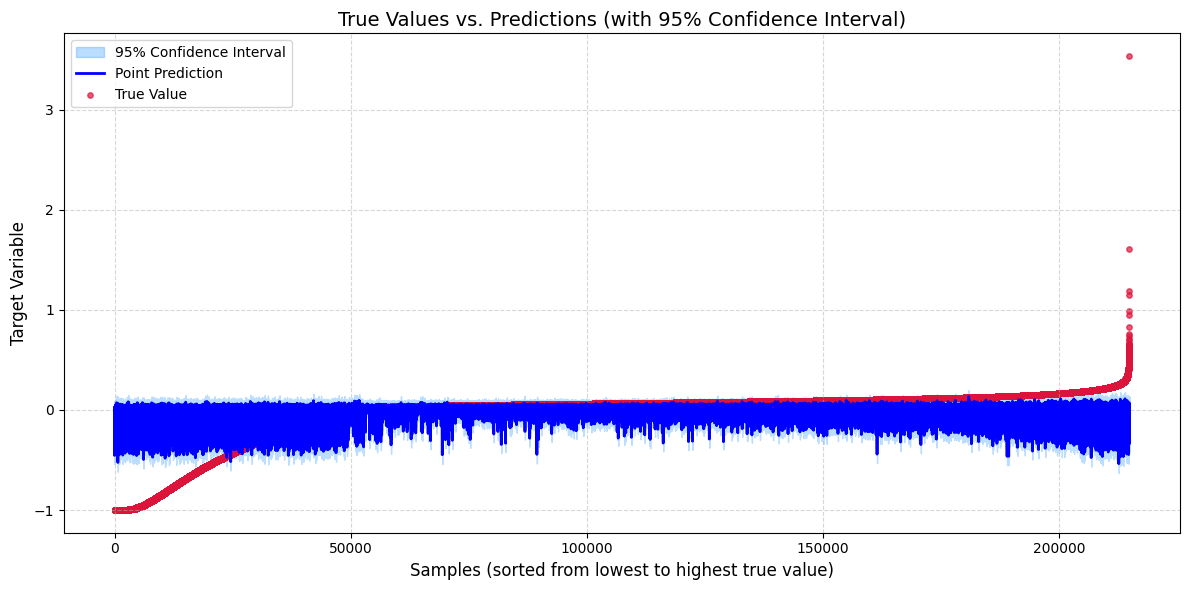

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the bounds of the 95% confidence interval (Z-score is approx. 1.96)
z_score = 1.96
lower_bound = holdout_point - z_score * holdout_std
upper_bound = holdout_point + z_score * holdout_std

sort_idx = np.argsort(y_val_holdout.values)
y_true_sorted = y_val_holdout.values[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

plt.figure(figsize=(12, 6))

plt.fill_between(range(len(y_true_sorted)), lower_sorted, upper_sorted, 
                 color='dodgerblue', alpha=0.3, label='95% Confidence Interval')

plt.plot(range(len(y_true_sorted)), y_pred_sorted, color='blue', linewidth=2, label='Point Prediction')

plt.scatter(range(len(y_true_sorted)), y_true_sorted, color='crimson', s=15, alpha=0.7, label='True Value')

plt.title('True Values vs. Predictions (with 95% Confidence Interval)', fontsize=14)
plt.xlabel('Samples (sorted from lowest to highest true value)', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

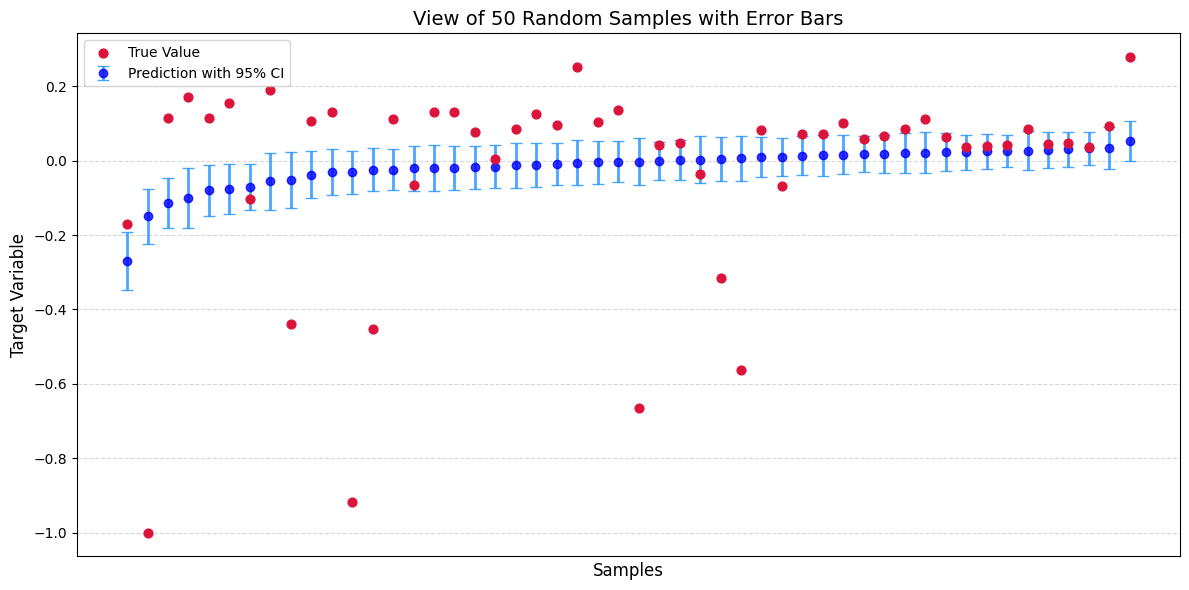

In [52]:
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

y_true_sample = y_val_holdout.values[sample_idx]
y_pred_sample = holdout_point[sample_idx]
std_sample = holdout_std[sample_idx]

sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
std_sample = std_sample[sort_idx]

plt.figure(figsize=(12, 6))

plt.errorbar(range(n_samples), y_pred_sample, yerr=1.96 * std_sample, 
             fmt='o', color='blue', ecolor='dodgerblue', elinewidth=2, capsize=4, 
             alpha=0.8, label='Prediction with 95% CI')

plt.scatter(range(n_samples), y_true_sample, color='crimson', s=40, zorder=3, label='True Value')

plt.title(f'View of {n_samples} Random Samples with Error Bars', fontsize=14)
plt.xlabel('Samples', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Regression - CRPS

Using CRPS metric to optimze also the variance of prediction

[Parameters](https://pgbm.readthedocs.io/en/latest/parameters_sklearn.html)

### 1k

In [58]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from pgbm.sklearn import HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from pgbm.sklearn import crps_ensemble
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)


# Parameter tuning settings

timeout_seconds = 60*60*0.5
no_improvement_trials = 100

# Split the 1k dataset to evaluate on holdout after tuning
# Had problem with overfitting and extreme bad results on last 200 rows so switched the order

X_tuning = train_1k_X.tail(800)
y_tuning = train_1k_y_reg.tail(800)
X_val_holdout = train_1k_X.head(200)
y_val_holdout = train_1k_y_reg.head(200)

def objective_pgbm(trial):
    params = {
        "max_iter": trial.suggest_int("max_iter", 100, 1000), # Number of boosting rounds
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "max_depth": trial.suggest_int("max_depth", 2, 8), # Max tree depth
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 15, 100), # Min samples required in a leaf node
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 3, 31), # Max leaf nodes in the tree
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-5, 100.0, log=True), # L2 regularization term on weights
        "random_state": 42, # For reproducibility
        "verbose": 0, # No verbose output during training
        "max_bins": trial.suggest_int("max_bins", 63, 255), # Maximum number of bins to use for discretizing continuous features
        "tree_correlation": trial.suggest_float("tree_correlation", 1e-4, 0.1, log=True), # Minimum correlation required between trees to allow them to be added to the ensemble
        "distribution": trial.suggest_categorical("distribution", ["normal", "studentt", "laplace", "logistic"]), # Loss function to optimize
        "with_variance": True, # Whether to compute variance estimates for predictions
    }

    if params["distribution"] == "studentt":
        params["studentt_degrees_of_freedom"] = trial.suggest_float("studentt_degrees_of_freedom", 2.0, 30.0) # Degrees of freedom for Student's t distribution

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        HistGradientBoostingRegressor(**params)
    )
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr, y_val = y_tuning.iloc[train_idx], y_tuning.iloc[val_idx]
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            full_pipeline.fit(X_tr, y_tr)
        
        preds_point, preds_std = full_pipeline.predict(X_val, return_std=True)
        preds_dist = full_pipeline.named_steps['histgradientboostingregressor'].sample(preds_point, preds_std, n_estimates=1000)
        
        crps = crps_ensemble(preds_dist, y_val.values)
        cv_scores.append(crps)
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best CRPS for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_pgbm = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_pgbm.optimize(objective_pgbm, timeout=timeout_seconds, n_jobs=1, callbacks=[stop_optuna], show_progress_bar=False)

print("\n" + "="*40)
print(f"BEST CRPS: {study_pgbm.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_pgbm.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_pgbm)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_pgbm)
fig1.show()
    
fig2 = plot_param_importances(study_pgbm)
fig2.show()
    
fig3 = plot_parallel_coordinate(
    study_pgbm,
    params=[
        "max_iter", 
        "learning_rate", 
        "max_depth", 
        "min_samples_leaf", 
        "max_leaf_nodes", 
        "l2_regularization",
        "max_bins",
        "tree_correlation",
        "distribution",
    ]
    )
fig3.show()
    
fig1.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_crps_1k_history.html")
fig2.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_crps_1k_importance.html")
fig3.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_crps_1k_parallel.html")


[I 2026-04-27 11:33:20,921] A new study created in memory with name: no-name-2f5ba75b-1526-466f-b916-947d9f9a3827
[I 2026-04-27 11:33:23,703] Trial 0 finished with value: 0.20129827476198045 and parameters: {'max_iter': 437, 'learning_rate': 0.1667521176194013, 'max_depth': 7, 'min_samples_leaf': 66, 'max_leaf_nodes': 7, 'l2_regularization': 0.0001235838277230692, 'max_bins': 74, 'tree_correlation': 0.0396760507705299, 'distribution': 'logistic'}. Best is trial 0 with value: 0.20129827476198045.
[I 2026-04-27 11:33:29,065] Trial 1 finished with value: 0.21325930388188982 and parameters: {'max_iter': 850, 'learning_rate': 0.010943342660062645, 'max_depth': 3, 'min_samples_leaf': 30, 'max_leaf_nodes': 11, 'l2_regularization': 0.047129737561107825, 'max_bins': 146, 'tree_correlation': 0.0007476312062252305, 'distribution': 'normal'}. Best is trial 0 with value: 0.20129827476198045.
[I 2026-04-27 11:33:31,861] Trial 2 finished with value: 0.19679902411948505 and parameters: {'max_iter': 51


[Early Stop] No improvement in 100 trials. Stopping optimization.

BEST CRPS: 0.1817
BEST PARAMETERS:
best_params = {
    "max_iter": 118,
    "learning_rate": 0.0825427767613178,
    "max_depth": 2,
    "min_samples_leaf": 100,
    "max_leaf_nodes": 6,
    "l2_regularization": 0.0005257335674130078,
    "max_bins": 240,
    "tree_correlation": 0.00011377346535888932,
    "distribution": "normal",
}

--- PARAMETER IMPORTANCE ---
  learning_rate       : 0.6308
  max_iter            : 0.2959
  min_samples_leaf    : 0.0276
  max_leaf_nodes      : 0.0191
  max_bins            : 0.0120
  max_depth           : 0.0053
  tree_correlation    : 0.0043
  distribution        : 0.0029
  l2_regularization   : 0.0021


In [59]:
# Check overfit on holdout set with best parameters from tuning

best_params = study_pgbm.best_params.copy()
best_params["random_state"] = 42
best_params["verbose"] = 0
best_params["with_variance"] = True
print(f"BEST PARAMS: {best_params}")

final_pipeline = make_pipeline(
    numeric_preprocessor,
    HistGradientBoostingRegressor(**best_params)
)

final_pipeline.fit(X_tuning, y_tuning)
holdout_point, holdout_std = final_pipeline.predict(X_val_holdout, return_std=True)
holdout_dist = final_pipeline.named_steps['histgradientboostingregressor'].sample(holdout_point, holdout_std, n_estimates=1000)

holdout_crps = crps_ensemble(holdout_dist, y_val_holdout.values)
holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout.values, holdout_point))

print("\n" + "="*40)
print(f"Optuna Val CRPS:   {study_pgbm.best_value:.4f}")
print(f"Holdout Test CRPS: {holdout_crps:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("="*40)


BEST PARAMS: {'max_iter': 118, 'learning_rate': 0.0825427767613178, 'max_depth': 2, 'min_samples_leaf': 100, 'max_leaf_nodes': 6, 'l2_regularization': 0.0005257335674130078, 'max_bins': 240, 'tree_correlation': 0.00011377346535888932, 'distribution': 'normal', 'random_state': 42, 'verbose': 0, 'with_variance': True}

Optuna Val CRPS:   0.1817
Holdout Test CRPS: 0.1525
Holdout Test RMSE: 0.2964


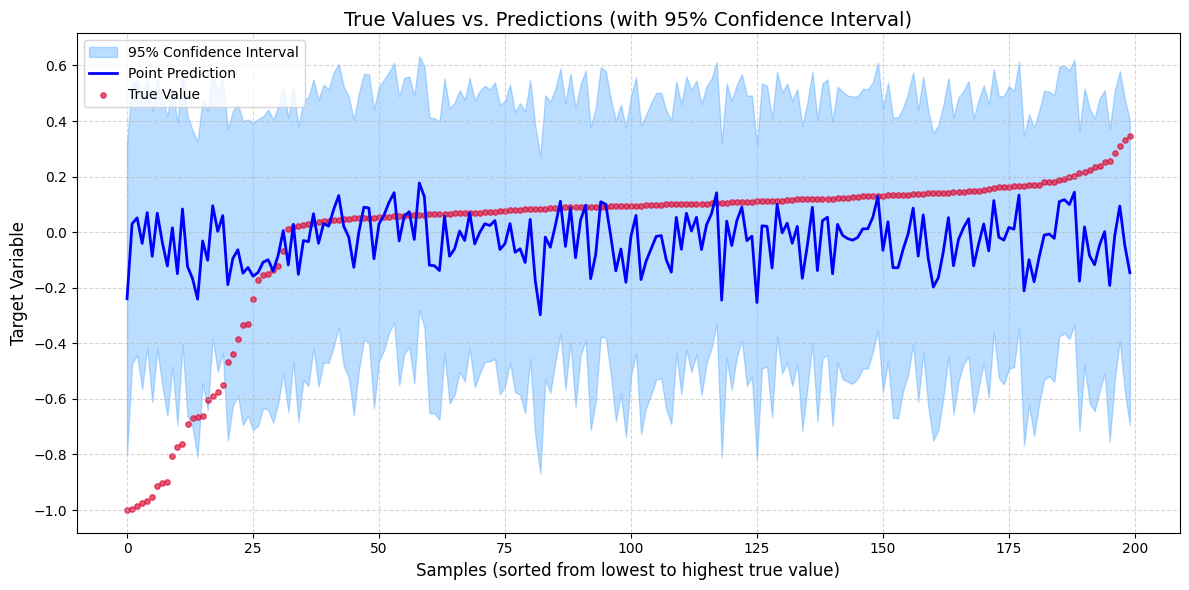

In [60]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the bounds of the 95% confidence interval (Z-score is approx. 1.96)
z_score = 1.96
lower_bound = holdout_point - z_score * holdout_std
upper_bound = holdout_point + z_score * holdout_std

sort_idx = np.argsort(y_val_holdout.values)
y_true_sorted = y_val_holdout.values[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

plt.figure(figsize=(12, 6))

plt.fill_between(range(len(y_true_sorted)), lower_sorted, upper_sorted, 
                 color='dodgerblue', alpha=0.3, label='95% Confidence Interval')

plt.plot(range(len(y_true_sorted)), y_pred_sorted, color='blue', linewidth=2, label='Point Prediction')

plt.scatter(range(len(y_true_sorted)), y_true_sorted, color='crimson', s=15, alpha=0.7, label='True Value')

plt.title('True Values vs. Predictions (with 95% Confidence Interval)', fontsize=14)
plt.xlabel('Samples (sorted from lowest to highest true value)', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

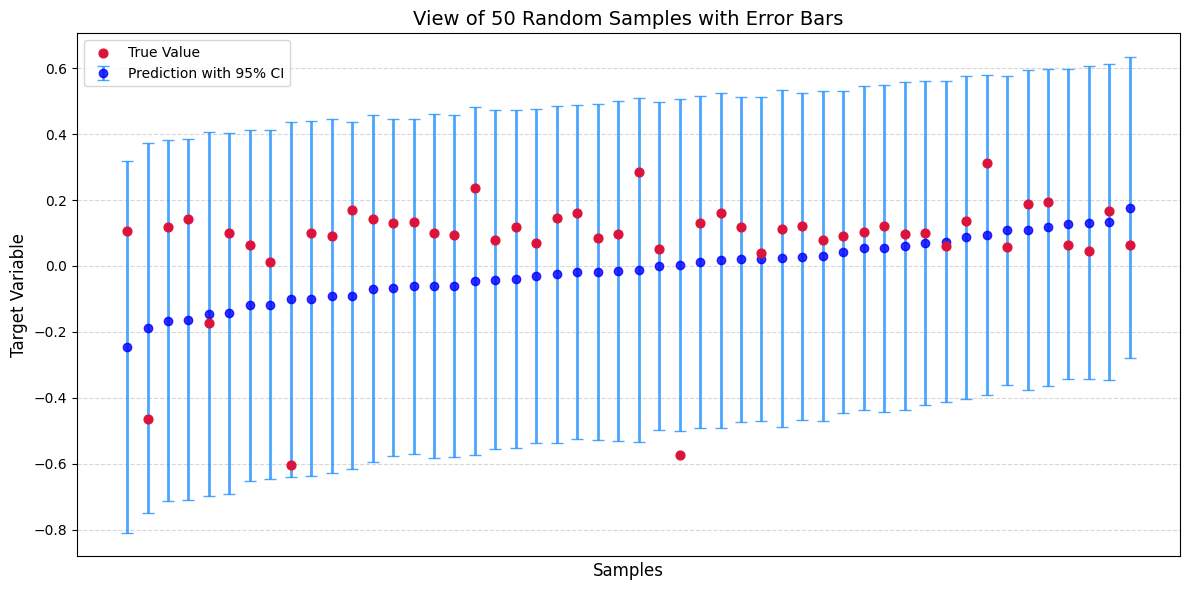

In [61]:
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

y_true_sample = y_val_holdout.values[sample_idx]
y_pred_sample = holdout_point[sample_idx]
std_sample = holdout_std[sample_idx]

sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
std_sample = std_sample[sort_idx]

plt.figure(figsize=(12, 6))

plt.errorbar(range(n_samples), y_pred_sample, yerr=1.96 * std_sample, 
             fmt='o', color='blue', ecolor='dodgerblue', elinewidth=2, capsize=4, 
             alpha=0.8, label='Prediction with 95% CI')

plt.scatter(range(n_samples), y_true_sample, color='crimson', s=40, zorder=3, label='True Value')

plt.title(f'View of {n_samples} Random Samples with Error Bars', fontsize=14)
plt.xlabel('Samples', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 10k

In [62]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from pgbm.sklearn import HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from pgbm.sklearn import crps_ensemble


# Parameter tuning settings

timeout_seconds = 60*60*1
no_improvement_trials = 100

# Split the 10k dataset to evaluate on holdout after tuning

X_tuning = train_10k_X.head(8000)
y_tuning = train_10k_y_reg.head(8000)
X_val_holdout = train_10k_X.tail(2000)
y_val_holdout = train_10k_y_reg.tail(2000)

def objective_pgbm(trial):
    params = {
        "max_iter": trial.suggest_int("max_iter", 100, 1000), # Number of boosting rounds
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True), # Step size
        "max_depth": trial.suggest_int("max_depth", 2, 8), # Max tree depth
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 15, 100), # Min samples required in a leaf node
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 3, 31), # Max leaf nodes in the tree
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-5, 100.0, log=True), # L2 regularization term on weights
        "random_state": 42, # For reproducibility
        "verbose": 0, # No verbose output during training
        "max_bins": trial.suggest_int("max_bins", 63, 255), # Maximum number of bins to use for discretizing continuous features
        "tree_correlation": trial.suggest_float("tree_correlation", 1e-4, 0.1, log=True), # Minimum correlation required between trees to allow them to be added to the ensemble
        "distribution": trial.suggest_categorical("distribution", ["normal", "studentt", "laplace", "logistic"]), # Loss function to optimize
        "with_variance": True # Whether to compute variance estimates for predictions
    }

    if params["distribution"] == "studentt":
        params["studentt_degrees_of_freedom"] = trial.suggest_float("studentt_degrees_of_freedom", 2.0, 30.0) # Degrees of freedom for Student's t distribution

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        HistGradientBoostingRegressor(**params)
    )
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr, y_val = y_tuning.iloc[train_idx], y_tuning.iloc[val_idx]
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            full_pipeline.fit(X_tr, y_tr)
        
        preds_point, preds_std = full_pipeline.predict(X_val, return_std=True)
        preds_dist = full_pipeline.named_steps['histgradientboostingregressor'].sample(preds_point, preds_std, n_estimates=1000)
        
        crps = crps_ensemble(preds_dist, y_val.values)
        cv_scores.append(crps)
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best CRPS for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_pgbm = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_pgbm.optimize(objective_pgbm, timeout=timeout_seconds, n_jobs=1, callbacks=[stop_optuna], show_progress_bar=False)

print("\n" + "="*40)
print(f"BEST CRPS: {study_pgbm.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_pgbm.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_pgbm)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_pgbm)
fig1.show()
    
fig2 = plot_param_importances(study_pgbm)
fig2.show()
    
fig3 = plot_parallel_coordinate(
    study_pgbm,
    params=[
        "max_iter", 
        "learning_rate", 
        "max_depth", 
        "min_samples_leaf", 
        "max_leaf_nodes", 
        "l2_regularization",
        "max_bins",
        "tree_correlation",
        "distribution",
    ]
    )
fig3.show()
    
fig1.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_crps_10k_history.html")
fig2.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_crps_10k_importance.html")
fig3.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_crps_10k_parallel.html")


[I 2026-04-27 11:37:01,954] A new study created in memory with name: no-name-39131e84-0784-45fb-9483-a017a89131dc
[I 2026-04-27 11:37:06,594] Trial 0 finished with value: 0.16282073152310064 and parameters: {'max_iter': 437, 'learning_rate': 0.1667521176194013, 'max_depth': 7, 'min_samples_leaf': 66, 'max_leaf_nodes': 7, 'l2_regularization': 0.0001235838277230692, 'max_bins': 74, 'tree_correlation': 0.0396760507705299, 'distribution': 'logistic'}. Best is trial 0 with value: 0.16282073152310064.
[I 2026-04-27 11:37:13,668] Trial 1 finished with value: 0.1632216855825256 and parameters: {'max_iter': 850, 'learning_rate': 0.010943342660062645, 'max_depth': 3, 'min_samples_leaf': 30, 'max_leaf_nodes': 11, 'l2_regularization': 0.047129737561107825, 'max_bins': 146, 'tree_correlation': 0.0007476312062252305, 'distribution': 'normal'}. Best is trial 0 with value: 0.16282073152310064.
[I 2026-04-27 11:37:17,935] Trial 2 finished with value: 0.16288129807616392 and parameters: {'max_iter': 510


[Early Stop] No improvement in 100 trials. Stopping optimization.

BEST CRPS: 0.1477
BEST PARAMETERS:
best_params = {
    "max_iter": 101,
    "learning_rate": 0.088906619139551,
    "max_depth": 6,
    "min_samples_leaf": 54,
    "max_leaf_nodes": 3,
    "l2_regularization": 0.1386740146740334,
    "max_bins": 78,
    "tree_correlation": 0.01820508124245228,
    "distribution": "logistic",
}

--- PARAMETER IMPORTANCE ---
  learning_rate       : 0.7769
  max_bins            : 0.0590
  max_leaf_nodes      : 0.0480
  tree_correlation    : 0.0435
  max_iter            : 0.0341
  min_samples_leaf    : 0.0201
  distribution        : 0.0097
  max_depth           : 0.0061
  l2_regularization   : 0.0026


In [63]:
# Check overfit on holdout set with best parameters from tuning

best_params = study_pgbm.best_params.copy()
best_params["random_state"] = 42
best_params["verbose"] = 0
best_params["with_variance"] = True
best_params["max_iter"] = int(best_params["max_iter"] * 1)
best_params["learning_rate"] = best_params["learning_rate"] / 1
print(f"BEST PARAMS: {best_params}")

final_pipeline = make_pipeline(
    numeric_preprocessor,
    HistGradientBoostingRegressor(**best_params)
)

final_pipeline.fit(X_tuning, y_tuning)
holdout_point, holdout_std = final_pipeline.predict(X_val_holdout, return_std=True)
holdout_dist = final_pipeline.named_steps['histgradientboostingregressor'].sample(holdout_point, holdout_std, n_estimates=1000)

holdout_crps = crps_ensemble(holdout_dist, y_val_holdout.values)
holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout.values, holdout_point))

print("\n" + "="*40)
print(f"Optuna Val CRPS:   {study_pgbm.best_value:.4f}")
print(f"Holdout Test CRPS: {holdout_crps:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("="*40)

BEST PARAMS: {'max_iter': 101, 'learning_rate': 0.088906619139551, 'max_depth': 6, 'min_samples_leaf': 54, 'max_leaf_nodes': 3, 'l2_regularization': 0.1386740146740334, 'max_bins': 78, 'tree_correlation': 0.01820508124245228, 'distribution': 'logistic', 'random_state': 42, 'verbose': 0, 'with_variance': True}

Optuna Val CRPS:   0.1477
Holdout Test CRPS: 0.1682
Holdout Test RMSE: 0.3206


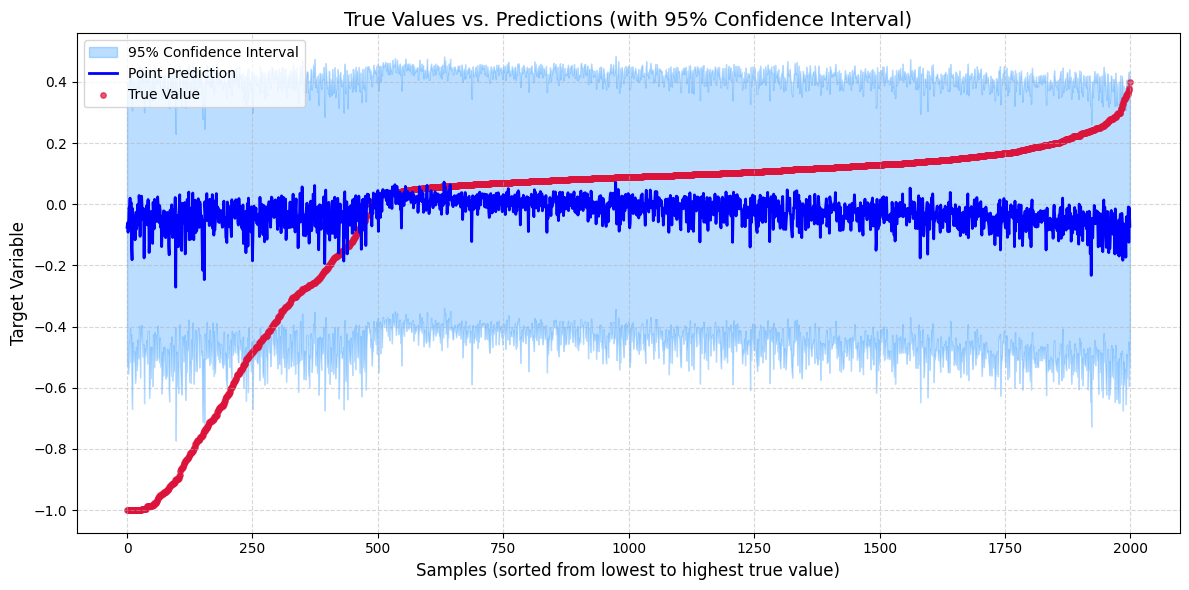

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the bounds of the 95% confidence interval (Z-score is approx. 1.96)
z_score = 1.96
lower_bound = holdout_point - z_score * holdout_std
upper_bound = holdout_point + z_score * holdout_std

sort_idx = np.argsort(y_val_holdout.values)
y_true_sorted = y_val_holdout.values[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

plt.figure(figsize=(12, 6))

plt.fill_between(range(len(y_true_sorted)), lower_sorted, upper_sorted, 
                 color='dodgerblue', alpha=0.3, label='95% Confidence Interval')

plt.plot(range(len(y_true_sorted)), y_pred_sorted, color='blue', linewidth=2, label='Point Prediction')

plt.scatter(range(len(y_true_sorted)), y_true_sorted, color='crimson', s=15, alpha=0.7, label='True Value')

plt.title('True Values vs. Predictions (with 95% Confidence Interval)', fontsize=14)
plt.xlabel('Samples (sorted from lowest to highest true value)', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

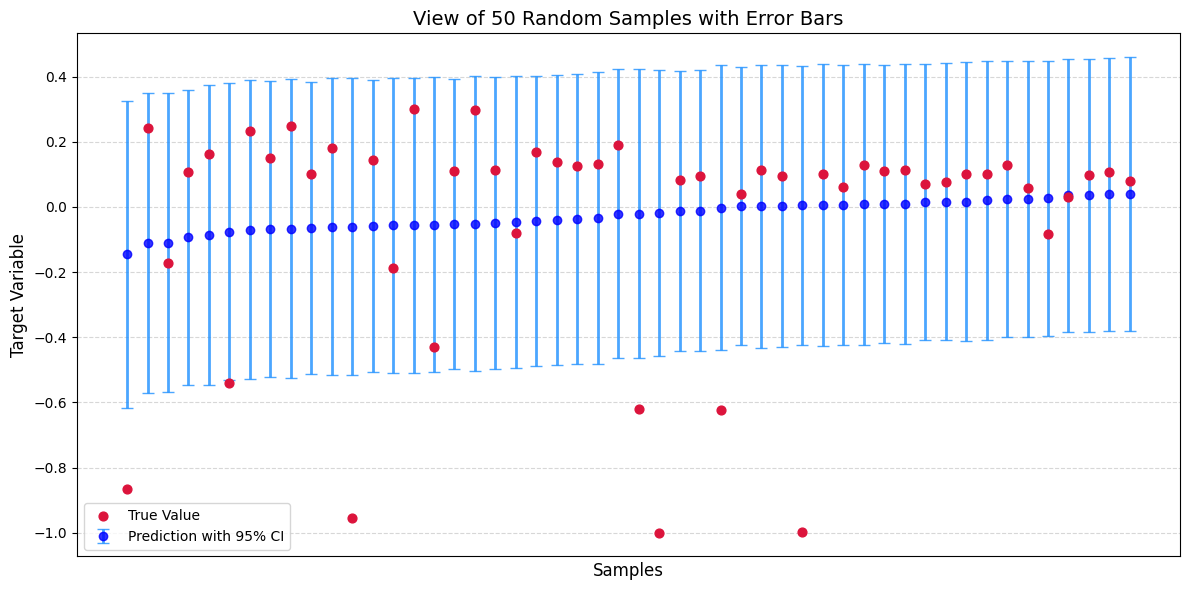

In [65]:
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

y_true_sample = y_val_holdout.values[sample_idx]
y_pred_sample = holdout_point[sample_idx]
std_sample = holdout_std[sample_idx]

sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
std_sample = std_sample[sort_idx]

plt.figure(figsize=(12, 6))

plt.errorbar(range(n_samples), y_pred_sample, yerr=1.96 * std_sample, 
             fmt='o', color='blue', ecolor='dodgerblue', elinewidth=2, capsize=4, 
             alpha=0.8, label='Prediction with 95% CI')

plt.scatter(range(n_samples), y_true_sample, color='crimson', s=40, zorder=3, label='True Value')

plt.title(f'View of {n_samples} Random Samples with Error Bars', fontsize=14)
plt.xlabel('Samples', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 100k

In [66]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from pgbm.sklearn import HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from pgbm.sklearn import crps_ensemble


# Parameter tuning settings

timeout_seconds = 60*60*3
no_improvement_trials = 100

# Split the 100k dataset to evaluate on holdout after tuning

X_tuning = train_100k_X.head(80000)
y_tuning = train_100k_y_reg.head(80000)
X_val_holdout = train_100k_X.tail(20000)
y_val_holdout = train_100k_y_reg.tail(20000)

def objective_pgbm(trial):
    params = {
        "max_iter": trial.suggest_int("max_iter", 100, 1000), # Number of boosting rounds
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.2, log=True), # Step size
        "max_depth": trial.suggest_int("max_depth", 2, 20), # Max tree depth
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 500), # Min samples required in a leaf node
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 5, 512), # Max leaf nodes in the tree
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-5, 100.0, log=True), # L2 regularization term on weights
        "random_state": 42, # For reproducibility
        "verbose": 0, # No verbose output during training
        "max_bins": trial.suggest_int("max_bins", 63, 255), # Maximum number of bins to use for discretizing continuous features
        "tree_correlation": trial.suggest_float("tree_correlation", 1e-4, 0.1, log=True), # Minimum correlation required between trees to allow them to be added to the ensemble
        "distribution": trial.suggest_categorical("distribution", ["normal", "studentt", "laplace", "logistic"]), # Loss function to optimize
        "with_variance": True # Whether to compute variance estimates for predictions
    }

    if params["distribution"] == "studentt":
        params["studentt_degrees_of_freedom"] = trial.suggest_float("studentt_degrees_of_freedom", 2.0, 30.0) # Degrees of freedom for Student's t distribution

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        HistGradientBoostingRegressor(**params)
    )
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr, y_val = y_tuning.iloc[train_idx], y_tuning.iloc[val_idx]
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            full_pipeline.fit(X_tr, y_tr)
        
        preds_point, preds_std = full_pipeline.predict(X_val, return_std=True)
        preds_dist = full_pipeline.named_steps['histgradientboostingregressor'].sample(preds_point, preds_std, n_estimates=1000)
        
        crps = crps_ensemble(preds_dist, y_val.values)
        cv_scores.append(crps)
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best CRPS for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_pgbm = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_pgbm.optimize(objective_pgbm, timeout=timeout_seconds, n_jobs=1, callbacks=[stop_optuna], show_progress_bar=False)

print("\n" + "="*40)
print(f"BEST CRPS: {study_pgbm.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_pgbm.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_pgbm)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_pgbm)
fig1.show()
    
fig2 = plot_param_importances(study_pgbm)
fig2.show()
    
fig3 = plot_parallel_coordinate(
    study_pgbm,
    params=[
        "max_iter", 
        "learning_rate", 
        "max_depth", 
        "min_samples_leaf", 
        "max_leaf_nodes", 
        "l2_regularization",
        "max_bins",
        "tree_correlation",
        "distribution",
    ]
    )
fig3.show()
    
fig1.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_crps_100k_history.html")
fig2.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_crps_100k_importance.html")
fig3.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_crps_100k_parallel.html")

[I 2026-04-27 11:53:06,058] A new study created in memory with name: no-name-58113fce-75d4-4f05-921a-15d04d69d60f
[I 2026-04-27 11:53:12,610] Trial 0 finished with value: 0.1570592311472974 and parameters: {'max_iter': 437, 'learning_rate': 0.1540359659501924, 'max_depth': 15, 'min_samples_leaf': 303, 'max_leaf_nodes': 84, 'l2_regularization': 0.0001235838277230692, 'max_bins': 74, 'tree_correlation': 0.0396760507705299, 'distribution': 'logistic'}. Best is trial 0 with value: 0.1570592311472974.
[I 2026-04-27 11:54:10,147] Trial 1 finished with value: 0.20198205023603988 and parameters: {'max_iter': 850, 'learning_rate': 0.0030803400529839683, 'max_depth': 5, 'min_samples_leaf': 100, 'max_leaf_nodes': 159, 'l2_regularization': 0.047129737561107825, 'max_bins': 146, 'tree_correlation': 0.0007476312062252305, 'distribution': 'normal'}. Best is trial 0 with value: 0.1570592311472974.
[I 2026-04-27 11:54:17,735] Trial 2 finished with value: 0.16040526417293952 and parameters: {'max_iter':


[Early Stop] No improvement in 100 trials. Stopping optimization.

BEST CRPS: 0.1550
BEST PARAMETERS:
best_params = {
    "max_iter": 942,
    "learning_rate": 0.16852745776554806,
    "max_depth": 19,
    "min_samples_leaf": 400,
    "max_leaf_nodes": 355,
    "l2_regularization": 0.43331171136970614,
    "max_bins": 161,
    "tree_correlation": 0.0002951506064953749,
    "distribution": "logistic",
}

--- PARAMETER IMPORTANCE ---
  learning_rate       : 0.9522
  min_samples_leaf    : 0.0211
  max_depth           : 0.0187
  max_iter            : 0.0030
  tree_correlation    : 0.0019
  max_leaf_nodes      : 0.0013
  distribution        : 0.0008
  l2_regularization   : 0.0005
  max_bins            : 0.0005


In [67]:
# Check overfit on holdout set with best parameters from tuning

best_params = study_pgbm.best_params.copy()
best_params["random_state"] = 42
best_params["verbose"] = 0
best_params["with_variance"] = True
best_params["max_iter"] = int(best_params["max_iter"] * 1)
best_params["learning_rate"] = best_params["learning_rate"] / 1
print(f"BEST PARAMS: {best_params}")

final_pipeline = make_pipeline(
    numeric_preprocessor,
    HistGradientBoostingRegressor(**best_params)
)

final_pipeline.fit(X_tuning, y_tuning)
holdout_point, holdout_std = final_pipeline.predict(X_val_holdout, return_std=True)
holdout_dist = final_pipeline.named_steps['histgradientboostingregressor'].sample(holdout_point, holdout_std, n_estimates=1000)

holdout_crps = crps_ensemble(holdout_dist, y_val_holdout.values)
holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout.values, holdout_point))

print("\n" + "="*40)
print(f"Optuna Val CRPS:   {study_pgbm.best_value:.4f}")
print(f"Holdout Test CRPS: {holdout_crps:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("="*40)

BEST PARAMS: {'max_iter': 942, 'learning_rate': 0.16852745776554806, 'max_depth': 19, 'min_samples_leaf': 400, 'max_leaf_nodes': 355, 'l2_regularization': 0.43331171136970614, 'max_bins': 161, 'tree_correlation': 0.0002951506064953749, 'distribution': 'logistic', 'random_state': 42, 'verbose': 0, 'with_variance': True}

Optuna Val CRPS:   0.1550
Holdout Test CRPS: 0.1561
Holdout Test RMSE: 0.3023


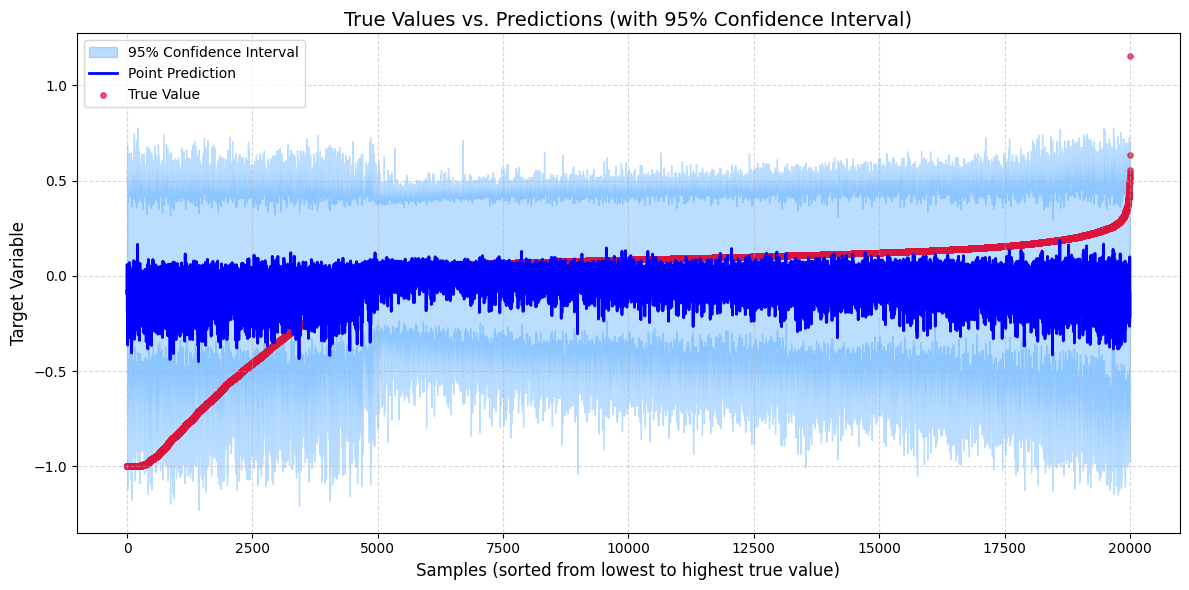

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the bounds of the 95% confidence interval (Z-score is approx. 1.96)
z_score = 1.96
lower_bound = holdout_point - z_score * holdout_std
upper_bound = holdout_point + z_score * holdout_std

sort_idx = np.argsort(y_val_holdout.values)
y_true_sorted = y_val_holdout.values[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

plt.figure(figsize=(12, 6))

plt.fill_between(range(len(y_true_sorted)), lower_sorted, upper_sorted, 
                 color='dodgerblue', alpha=0.3, label='95% Confidence Interval')

plt.plot(range(len(y_true_sorted)), y_pred_sorted, color='blue', linewidth=2, label='Point Prediction')

plt.scatter(range(len(y_true_sorted)), y_true_sorted, color='crimson', s=15, alpha=0.7, label='True Value')

plt.title('True Values vs. Predictions (with 95% Confidence Interval)', fontsize=14)
plt.xlabel('Samples (sorted from lowest to highest true value)', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

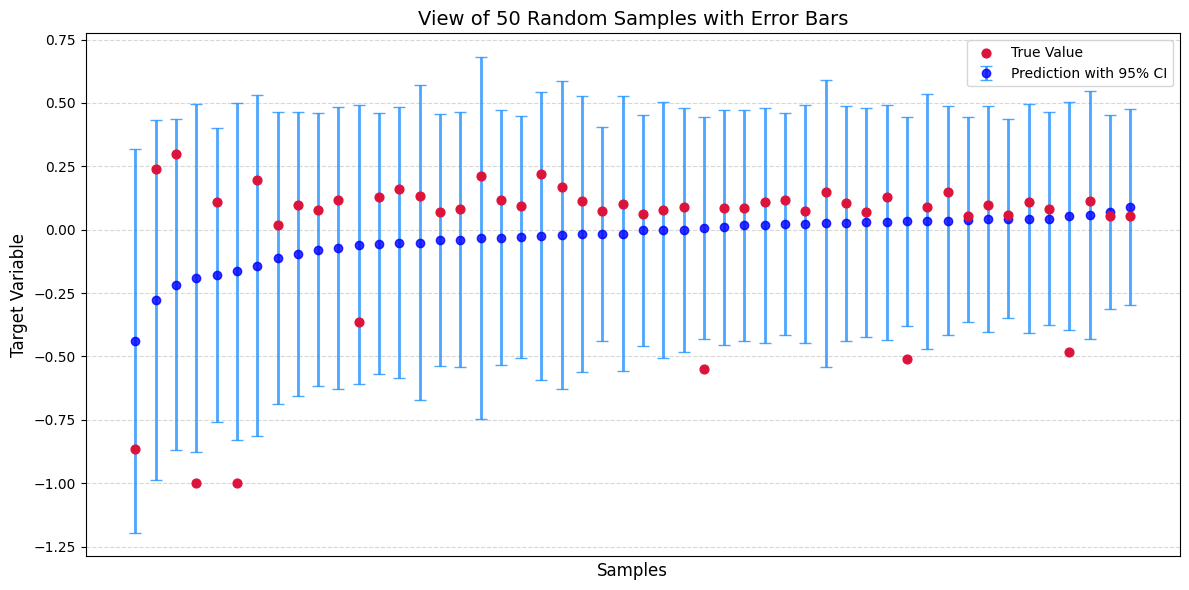

In [69]:
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

y_true_sample = y_val_holdout.values[sample_idx]
y_pred_sample = holdout_point[sample_idx]
std_sample = holdout_std[sample_idx]

sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
std_sample = std_sample[sort_idx]

plt.figure(figsize=(12, 6))

plt.errorbar(range(n_samples), y_pred_sample, yerr=1.96 * std_sample, 
             fmt='o', color='blue', ecolor='dodgerblue', elinewidth=2, capsize=4, 
             alpha=0.8, label='Prediction with 95% CI')

plt.scatter(range(n_samples), y_true_sample, color='crimson', s=40, zorder=3, label='True Value')

plt.title(f'View of {n_samples} Random Samples with Error Bars', fontsize=14)
plt.xlabel('Samples', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Whole training data set

In [33]:
import optuna
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from pgbm.sklearn import HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from pgbm.sklearn import crps_ensemble


# Parameter tuning settings

timeout_seconds = 60*60*4
no_improvement_trials = 100

split_index = int(len(train_full_X) * 0.8)

X_tuning = train_full_X[:split_index]
y_tuning = train_full_y_reg[:split_index]
X_val_holdout = train_full_X[split_index:]
y_val_holdout = train_full_y_reg[split_index:]

def objective_pgbm(trial):
    params = {
        "max_iter": trial.suggest_int("max_iter", 100, 1000), # Number of boosting rounds
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.2, log=True), # Step size
        "max_depth": trial.suggest_int("max_depth", 2, 20), # Max tree depth
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 500), # Min samples required in a leaf node
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 5, 512), # Max leaf nodes in the tree
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-5, 100.0, log=True), # L2 regularization term on weights
        "random_state": 42, # For reproducibility
        "verbose": 0, # No verbose output during training
        "max_bins": trial.suggest_int("max_bins", 63, 255), # Maximum number of bins to use for discretizing continuous features
        "tree_correlation": trial.suggest_float("tree_correlation", 1e-4, 0.1, log=True), # Minimum correlation required between trees to allow them to be added to the ensemble
        "distribution": trial.suggest_categorical("distribution", ["normal", "studentt", "laplace", "logistic"]), # Loss function to optimize
        "with_variance": True # Whether to compute variance estimates for predictions
    }

    if params["distribution"] == "studentt":
        params["studentt_degrees_of_freedom"] = trial.suggest_float("studentt_degrees_of_freedom", 2.0, 30.0) # Degrees of freedom for Student's t distribution

    full_pipeline = make_pipeline(
        numeric_preprocessor,
        HistGradientBoostingRegressor(**params)
    )
    
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr, y_val = y_tuning.iloc[train_idx], y_tuning.iloc[val_idx]
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            full_pipeline.fit(X_tr, y_tr)
        
        preds_point, preds_std = full_pipeline.predict(X_val, return_std=True)
        preds_dist = full_pipeline.named_steps['histgradientboostingregressor'].sample(preds_point, preds_std, n_estimates=1000)
        
        crps = crps_ensemble(preds_dist, y_val.values)
        cv_scores.append(crps)
        
    return np.mean(cv_scores)

def stop_optuna(study, trial): # Custom callback to stop optimization if no improvement in best CRPS for a certain number of trials
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization.")
        study.stop()

study_pgbm = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_pgbm.optimize(objective_pgbm, timeout=timeout_seconds, n_jobs=1, callbacks=[stop_optuna], show_progress_bar=False)

print("\n" + "="*40)
print(f"BEST CRPS: {study_pgbm.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_pgbm.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_pgbm)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("="*40)


fig1 = plot_optimization_history(study_pgbm)
fig1.show()
    
fig2 = plot_param_importances(study_pgbm)
fig2.show()
    
fig3 = plot_parallel_coordinate(
    study_pgbm,
    params=[
        "max_iter", 
        "learning_rate", 
        "max_depth", 
        "min_samples_leaf", 
        "max_leaf_nodes", 
        "l2_regularization",
        "max_bins",
        "tree_correlation",
        "distribution",
    ]
    )
fig3.show()
    
fig1.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_crps_full_history.html")
fig2.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_crps_full_importance.html")
fig3.write_html("hyperparameter_tuning/PGBM/Regression/optuna_pgbm_crps_full_parallel.html")

[I 2026-04-26 21:40:23,356] A new study created in memory with name: no-name-16731389-0649-4e82-9b6d-48f6acdc77c4
[I 2026-04-26 21:41:09,885] Trial 0 finished with value: 0.10796861584671132 and parameters: {'max_iter': 437, 'learning_rate': 0.1540359659501924, 'max_depth': 15, 'min_samples_leaf': 303, 'max_leaf_nodes': 84, 'l2_regularization': 0.0001235838277230692, 'max_bins': 74, 'tree_correlation': 0.0396760507705299, 'distribution': 'logistic'}. Best is trial 0 with value: 0.10796861584671132.
[I 2026-04-26 21:45:13,710] Trial 1 finished with value: 0.12061672068192282 and parameters: {'max_iter': 850, 'learning_rate': 0.0030803400529839683, 'max_depth': 5, 'min_samples_leaf': 100, 'max_leaf_nodes': 159, 'l2_regularization': 0.047129737561107825, 'max_bins': 146, 'tree_correlation': 0.0007476312062252305, 'distribution': 'normal'}. Best is trial 0 with value: 0.10796861584671132.
[I 2026-04-26 21:46:56,065] Trial 2 finished with value: 0.10970487253485837 and parameters: {'max_ite


BEST CRPS: 0.1031
BEST PARAMETERS:
best_params = {
    "max_iter": 169,
    "learning_rate": 0.08450958218537771,
    "max_depth": 19,
    "min_samples_leaf": 417,
    "max_leaf_nodes": 458,
    "l2_regularization": 0.3635116450476361,
    "max_bins": 130,
    "tree_correlation": 0.004300436828627492,
    "distribution": "laplace",
}

--- PARAMETER IMPORTANCE ---
  learning_rate       : 0.8517
  tree_correlation    : 0.0939
  max_depth           : 0.0181
  max_leaf_nodes      : 0.0149
  max_bins            : 0.0128
  distribution        : 0.0039
  max_iter            : 0.0030
  min_samples_leaf    : 0.0013
  l2_regularization   : 0.0004


In [34]:
# Check overfit on holdout set with best parameters from tuning

best_params = study_pgbm.best_params.copy()
best_params["random_state"] = 42
best_params["verbose"] = 0
best_params["with_variance"] = True
best_params["max_iter"] = int(best_params["max_iter"] * 1)
best_params["learning_rate"] = best_params["learning_rate"] / 1
print(f"BEST PARAMS: {best_params}")

final_pipeline = make_pipeline(
    numeric_preprocessor,
    HistGradientBoostingRegressor(**best_params)
)

final_pipeline.fit(X_tuning, y_tuning)
holdout_point, holdout_std = final_pipeline.predict(X_val_holdout, return_std=True)
holdout_dist = final_pipeline.named_steps['histgradientboostingregressor'].sample(holdout_point, holdout_std, n_estimates=1000)

holdout_crps = crps_ensemble(holdout_dist, y_val_holdout.values)
holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout.values, holdout_point))

print("\n" + "="*40)
print(f"Optuna Val CRPS:   {study_pgbm.best_value:.4f}")
print(f"Holdout Test CRPS: {holdout_crps:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("="*40)

BEST PARAMS: {'max_iter': 169, 'learning_rate': 0.08450958218537771, 'max_depth': 19, 'min_samples_leaf': 417, 'max_leaf_nodes': 458, 'l2_regularization': 0.3635116450476361, 'max_bins': 130, 'tree_correlation': 0.004300436828627492, 'distribution': 'laplace', 'random_state': 42, 'verbose': 0, 'with_variance': True}

Optuna Val CRPS:   0.1031
Holdout Test CRPS: 0.1382
Holdout Test RMSE: 0.2837


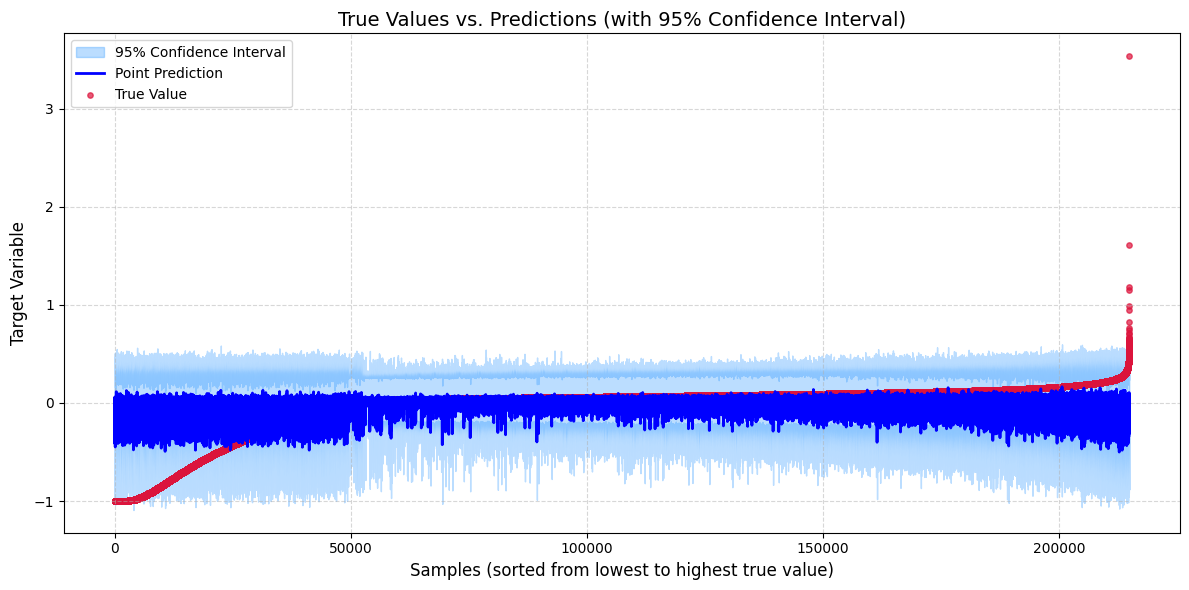

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the bounds of the 95% confidence interval (Z-score is approx. 1.96)
z_score = 1.96
lower_bound = holdout_point - z_score * holdout_std
upper_bound = holdout_point + z_score * holdout_std

sort_idx = np.argsort(y_val_holdout.values)
y_true_sorted = y_val_holdout.values[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

plt.figure(figsize=(12, 6))

plt.fill_between(range(len(y_true_sorted)), lower_sorted, upper_sorted, 
                 color='dodgerblue', alpha=0.3, label='95% Confidence Interval')

plt.plot(range(len(y_true_sorted)), y_pred_sorted, color='blue', linewidth=2, label='Point Prediction')

plt.scatter(range(len(y_true_sorted)), y_true_sorted, color='crimson', s=15, alpha=0.7, label='True Value')

plt.title('True Values vs. Predictions (with 95% Confidence Interval)', fontsize=14)
plt.xlabel('Samples (sorted from lowest to highest true value)', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

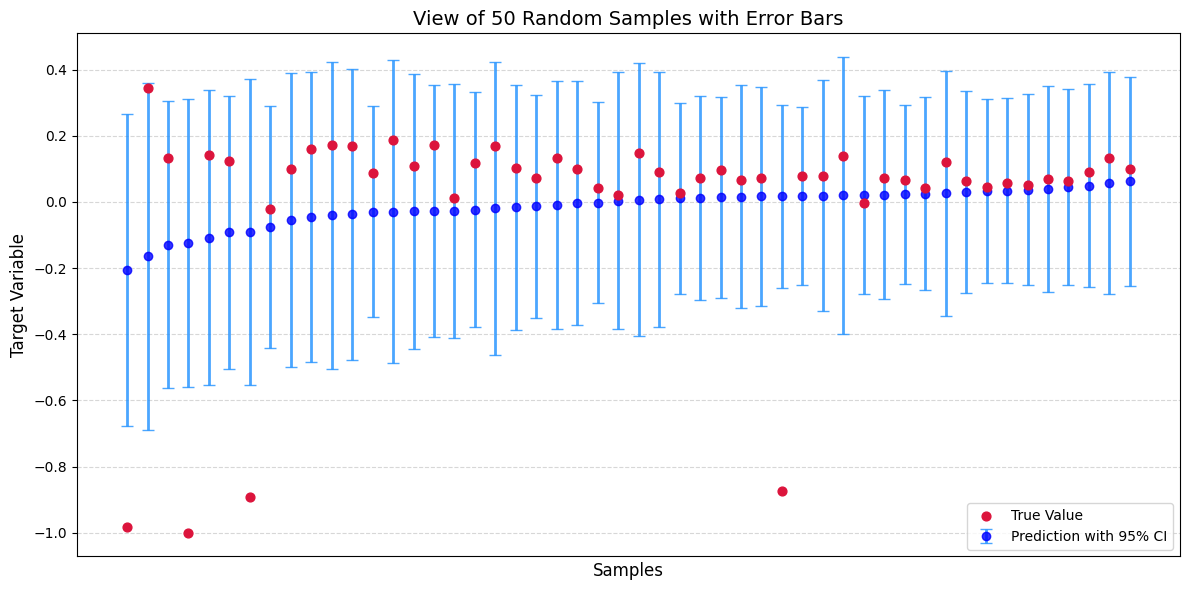

In [36]:
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

y_true_sample = y_val_holdout.values[sample_idx]
y_pred_sample = holdout_point[sample_idx]
std_sample = holdout_std[sample_idx]

sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
std_sample = std_sample[sort_idx]

plt.figure(figsize=(12, 6))

plt.errorbar(range(n_samples), y_pred_sample, yerr=1.96 * std_sample, 
             fmt='o', color='blue', ecolor='dodgerblue', elinewidth=2, capsize=4, 
             alpha=0.8, label='Prediction with 95% CI')

plt.scatter(range(n_samples), y_true_sample, color='crimson', s=40, zorder=3, label='True Value')

plt.title(f'View of {n_samples} Random Samples with Error Bars', fontsize=14)
plt.xlabel('Samples', fontsize=12)
plt.ylabel('Target Variable', fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()